Exploratory Data Analysis (EDA): FLSP, GCREW, TASK

Data Description: This study uses primary field and laboratory data collected from three Mid-Atlantic tidal creek systems: First Landing State Park (FLSP), Smithsonian Environmental Research Center (GCREW), and Taskinas Creek (TASK). Datasets include surface water (SW) time series measurements over different seasons and tidal cycles, as well as porewater (PW) and groundwater (GW) measurements. 

Data Integration: All datasets include radium (Ra) isotopes (223Ra, 224Ra, 226Ra, 228Ra), iostope ratios (224/223Ra, 224/226Ra, 224/228Ra, 226/228Ra), water quality parameters (temperature, salinity, pH, dissolved oxygen), depth, and total alkalinity (TA). The FLSP dataset contains nutrient (NOx, PO4, NH3, Si) data, and TASK contains silica (Si) data. Both GCREW and FLSP contain flowrate, CO2, and CH4 data. All datasets will contain DIC and DOC data, but only GCREW has finalized values right now. Some of the data, particularly for FLSP, is still in the works and will be filled in with NaN values for the time being. 

Data Overlap: 4 campaigns were conducted at GCREW to capture tidal (spring vs neap) and seasonal (summer vs winter) variabiliy. FLSP is designed the same way, but the winter campaign has not yet occured (anticipated winter 2027). 6 campaigns were conducted at TASK to assess seasonal variability (fall (x2), winter, spring (x2), summer), and one more campaign will be conducted this fall (2026).

All data provided was collected by myself or my collaborators at the Smithsonian Environmental Research Center (GCREW), Penn State University, and VIMS (TASK). 

In [2]:
import pandas as pd # helps us import files
import numpy as np # math
import matplotlib.pyplot as plt # makes figures 
import seaborn as sns # provides clean default styles
import cartopy as cp # handles map projections
import cartopy.crs as ccrs # handles map projections 
import cartopy.feature as cfeature # adds map features like basemaps, coastlines, rivers

In [36]:
# import data
infile_flsp = r'C:\Users\joann\FLSP-GCREW-TASK\DATA\raw\FLSP_export.csv'
infile_gcrew = r'C:\Users\joann\FLSP-GCREW-TASK\DATA\raw\GCREW_export.csv'
infile_task = r'C:\Users\joann\FLSP-GCREW-TASK\DATA\raw\TASK_export.csv'

data_flsp = pd.read_csv(infile_flsp, sep=',')
data_gcrew = pd.read_csv(infile_gcrew, sep=',')
data_task = pd.read_csv(infile_task, sep=',')

# see columns
print("--- FLSP ---") 
print(data_flsp.columns) 

print("\n--- GCREW ---") 
print(data_gcrew.columns) 

print("\n--- TASK ---")
print(data_task.columns) 

--- FLSP ---
Index(['Sample_ID', 'Season', 'Tidal_Cycle', 'Sample_Datetime', 'Time_local',
       'Sample_Type', 'Ra223_dpm100L', 'Ra223_err', 'Ra224_dpm100L',
       'Ra224_err', 'Ra226_dpm100L', 'Ra226_err', 'Ra228_dpmL', 'Ra228_err',
       'Ra224_223', 'Ra228_226', 'Ra224_228', 'Ra224_226', 'Ra224_Si',
       'Ra226_Si', 'Salinity', 'Depth_m', 'Temp_C', 'pH', 'ORP_mV', 'DO_sat',
       'DO_mg_L', 'SpcCon _uS_cm', 'FlowRate_m3_s', 'NOx', 'PO4', 'NH3',
       'Si_uM', 'fCO2_uatm', 'CH4_nM', 'DIC_umolL', 'DOC_umolL', 'TA_mmolkg'],
      dtype='str')

--- GCREW ---
Index(['Sample_ID', 'Sample_Type', 'Tidal_Cycle', 'Sample_Datetime',
       'volume_L', 'delta_volume_L', 'Ra223_dpm100L', 'Ra223_err',
       'Ra224_dpm100L', 'Ra224_err', 'Ra226_dpm100L', 'Ra226_err',
       'Ra228_dpm100L', 'Ra228_err', 'Ra224_223', 'Ra228_226', 'Ra224_228',
       'Ra224_226', 'Salinity', 'Time_local', 'Season', 'Depth_m', 'Temp_C',
       'DO_mg_L', 'Chlorophyll_ug_L', 'pH', 'amb_t_c', 'CO2d_ppm',
     

Spatial & Temporal Coverage:

First Landing State Park (FLSP) ghost forest: Located in Virginia Beach, VA (-75.995833, -76.009722, 36.886111, 36.888888); 2 campaigns in summer '26 (spring vs neap) and 2 anticipated winter '27 (12-hr time series)

Smithsonian Environmental Research Center (GCREW): Located in Edgewater, MD (-76.545833, -76.551944, 38.873055, 38.875277); 2 campaigns in summer '23 (spring vs neap) and 2 campaigns in winter '24 (12-hr time series)

Taskinas Creek (TASK): Located in York River State Park, VA (-76.714166, -76.716388, 37.413333, 37.415555); 6 campaigns total (fall '23, spring '24, summer '24, fall '24, winter '25, spring '25) and 1 anticipated fall '26 (24 & 12-hr time series)

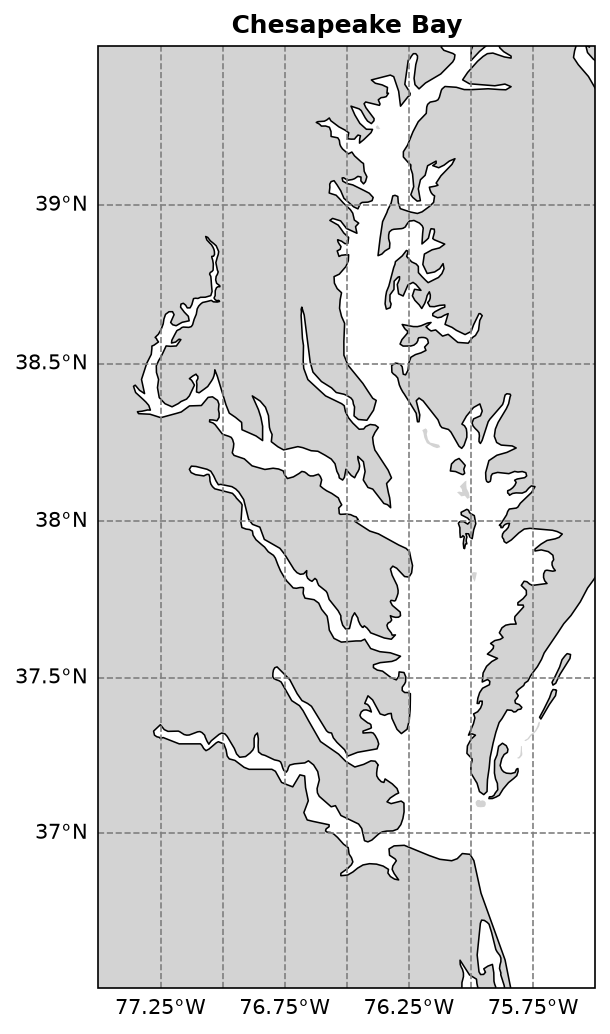

In [15]:
# create regional figure window for Chesapeake Bay
fig = plt.figure(figsize=(8, 7), dpi=150) # set comfortable display size

# add map subplot with Mercator projection
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator(
    central_longitude=0.0, min_latitude=20.0, max_latitude=55.0
)) # initialize mercator map axis

# set spatial extent: [west, east, south, north]
ax.set_extent([-77.5, -75.5, 36.5, 39.5], crs=ccrs.PlateCarree()) # crop map to Chesapeake Bay

# add coastlines and land basemap feature
ax.coastlines(linewidth=0.75, color='black') # draw coastlines
ax.add_feature(cp.feature.LAND, facecolor='lightgrey') # add land fill

# set figure title
ax.set_title('Chesapeake Bay', fontsize=12, fontweight='bold') # map title

# add gridlines for latitude and longitude
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.8, color='gray', linestyle='--') # add gridlines
gl.top_labels = False # hide top labels
gl.right_labels = False # hide right labels

# specify latitude tick locations across Chesapeake Bay
gl.ylocator = mticker.FixedLocator([37.0, 37.5, 38.0, 38.5, 39.0]) # set tick locations

plt.tight_layout() # adjust spacing
plt.show() # display map

The map above of the Chesapeake Bay will be panel A of my project map. I will had colored stars to this panel to mark where my three sites are located within this region. Panels B, C, and D will be zoomed in maps of my three sites, with the sample collection sites marked with different symbols or colors to differentiate PW/SW/GW.

In [18]:
# print the information about the data in the dataframe
print("=== FLSP ===") 
data_flsp.info() 

print("\n=== GCREW ===") 
data_gcrew.info() 

print("\n=== TASK ===") 
data_task.info() 

=== FLSP ===
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 38 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        32 non-null     str    
 1   Season           32 non-null     str    
 2   Tidal_Cycle      21 non-null     str    
 3   Sample_Datetime  32 non-null     str    
 4   Time_local       32 non-null     str    
 5   Sample_Type      32 non-null     str    
 6   Ra223_dpm100L    32 non-null     float64
 7   Ra223_err        32 non-null     float64
 8   Ra224_dpm100L    32 non-null     float64
 9   Ra224_err        32 non-null     float64
 10  Ra226_dpm100L    22 non-null     float64
 11  Ra226_err        22 non-null     float64
 12  Ra228_dpmL       0 non-null      float64
 13  Ra228_err        0 non-null      float64
 14  Ra224_223        32 non-null     float64
 15  Ra228_226        0 non-null      float64
 16  Ra224_228        0 non-null      float64
 17  Ra224_226       

Raw data loaded appropriately: string (texts/words), integer (whole numbers), floating-point number (numbers with decimal places). Empty cells appear to be filled with NaN placeholders (e.g. FLSP nutrients show 0 non-null). The code below will clarify which data columns contain missing values. 

In [20]:
print(f"FLSP: {data_flsp.isna().sum()}")
print(f"GCREW: {data_gcrew.isna().sum()}")
print(f"TASK: {data_task.isna().sum()}")

FLSP: Sample_ID           0
Season              0
Tidal_Cycle        11
Sample_Datetime     0
Time_local          0
Sample_Type         0
Ra223_dpm100L       0
Ra223_err           0
Ra224_dpm100L       0
Ra224_err           0
Ra226_dpm100L      10
Ra226_err          10
Ra228_dpmL         32
Ra228_err          32
Ra224_223           0
Ra228_226          32
Ra224_228          32
Ra224_226          10
Ra224_Si            0
Ra226_Si           10
Salinity            0
Depth_m             2
Temp_C              0
pH                  0
ORP_mV             21
DO_sat              0
DO_mg_L             0
SpcCon _uS_cm       0
FlowRate_m3_s      32
NOx                32
PO4                32
NH3                32
Si_uM               0
fCO2_uatm          21
CH4_nM             21
DIC_umolL          32
DOC_umolL          32
TA_mmolkg           0
dtype: int64
GCREW: Sample_ID              0
Sample_Type            0
Tidal_Cycle            0
Sample_Datetime        0
volume_L               0
delta_volume_

Data columns do contain missing values, particularly FLSP where majority of lab analyses have yet to be completed. Missing values align with blank cells in my .csv 

As I input more data into my .csv files I will rerun this code to ensure the data filled in the NaN placeholders.

In [8]:
# nrows, ncols
print(f"FLSP: {data_flsp.shape}") # print row and column count for FLSP
print(f"GCREW: {data_gcrew.shape}") # print row and column count for GCREW
print(f"TASK: {data_task.shape}") # print row and column count for TASK

FLSP: (35, 38)
GCREW: (78, 40)
TASK: (136, 33)


I will start my EDA by looking at each site individually, before doing any cross-site comparisons. I will start with GCREW since that is the most complete dataset.

In [48]:
# set pandas display option to show all columns
pd.set_option('display.max_rows', None)

# select key parameters to analyze 
gcrew_vars = [
    'Ra223_dpm100L', 'Ra224_dpm100L', 'Ra226_dpm100L', 'Ra228_dpm100L', 'Ra224_226',
    'Salinity', 'Temp_C', 'DO_mg_L', 'pH',
    'CO2d_ppm', 'CH4_nM', 'Rad_w_Bqm3',
    'DIC_umolL', 'DOC_umolL', 'TA_mmolkg',
    'FlowRate_m3_s', 'Depth_m'
] 

# calculate all descriptive stats grouped by Sample_Type
gcrew_endmember_stats = data_gcrew.groupby('Sample_Type')[gcrew_vars].describe() 

# transpose the table so parameters are rows and statistics are readable columns
gcrew_endmember_stats_formatted = gcrew_endmember_stats.T

# display the complete summary table
display(gcrew_endmember_stats_formatted) 

Sample_Type                    GW            PW            SW
Ra223_dpm100L count      6.000000     21.000000     51.000000
              mean       3.950000      8.833333      4.570588
              std        4.441058      6.400729      3.242055
              min        0.600000      0.200000      0.400000
              25%        1.400000      4.300000      1.950000
              50%        2.500000      8.500000      3.700000
              75%        3.975000     11.400000      7.250000
              max       12.600000     27.000000     12.700000
Ra224_dpm100L count      6.000000     20.000000     51.000000
              mean      56.283333    105.705000     56.117647
              std       73.969464     75.241880     40.086984
              min        9.700000     10.800000      6.800000
              25%       10.500000     53.425000     22.950000
              50%       31.100000     85.850000     46.400000
              75%       53.425000    134.275000     91.650000
              max      201.300000    326.400000    133.100000
Ra226_dpm100L count      6.000000     20.000000     49.000000
              mean     103.533333     43.640000     27.904082
              std      163.607001     24.643573     16.612219
              min       12.300000     10.600000     10.700000
              25%       17.000000     25.125000     11.800000
              50%       30.750000     43.500000     25.200000
              75%       86.200000     57.600000     43.500000
              max      430.300000     87.800000     59.200000
Ra228_dpm100L count      6.000000     21.000000     51.000000
              mean      85.666667    110.380952     52.882353
              std       47.038991    103.848195     24.110286
              min       41.000000     19.000000      8.000000
              25%       54.250000     60.000000     30.500000
              50%       68.000000     76.000000     56.000000
              75%      113.250000    121.000000     69.000000
              max      159.000000    482.000000    100.000000
Ra224_226     count      6.000000     20.000000     49.000000
              mean       0.813333      2.833500      2.009184
              std        0.600755      2.576583      0.390453
              min        0.300000      0.270000      1.140000
              25%        0.475000      1.625000      1.710000
              50%        0.640000      2.250000      2.030000
              75%        0.850000      3.047500      2.330000
              max        1.960000     12.650000      2.930000
Salinity      count      6.000000     21.000000     51.000000
              mean       5.581167      8.402857      6.606569
              std        2.119600      3.112143      1.863063
              min        3.687000      3.986000      3.986000
              25%        4.079750      4.772000      4.715500
              50%        4.696500     10.348000      7.150000
              75%        7.369000     10.463000      8.265000
              max        8.273000     11.758000     10.855000
Temp_C        count      6.000000     21.000000     51.000000
              mean      12.754750     18.731067     16.397824
              std       10.362967     10.550910     10.212745
              min        5.277300      5.277300      1.313600
              25%        5.699550      6.899300      6.764450
              50%        6.829850     27.371700     23.898600
              75%       21.324025     27.461700     26.104350
              max       26.113300     28.350800     30.333400
DO_mg_L       count      6.000000     21.000000     51.000000
              mean       9.768833      6.996905      6.918922
              std        7.630577      7.402296      6.963134
              min        0.080000      0.268000      0.060000
              25%        3.234250      0.541000      0.090500
              50%       13.100000      1.183000      2.171000
              75%       15.389250     15.424000     14.098500
              max       16.23500

On average, PW had the highest activities of the short-lived isotopes (Ra223, Ra224) and Ra228, but GW had the highest activities of Ra226. PW also had the highest 224/226Ra, which tracks with the higher 224 but lower 226 values. For water quality parameters, PW had the highest salinity (odd...fresher SW and potentially high evapotrans?) and the highest temperatures, but GW had the highest mean dissolved oxygen and pH. For gases, SW has the highest dissolved CO2 and methane, but GW had the highest radon concentrations. For carbonate chemistry, PW had the highest concentrations of DIC and DOC. TA data is still being processed for PW and GW. 

One thing I find striking is the large standard deviations, particularly for the Ra isotopes in GW and PW. This implies that the Ra values are highly variable, potentially due to the varying salinities between seasons. I will do correlation stats to see if there is a relationship between Ra activity and water quality parameters. 

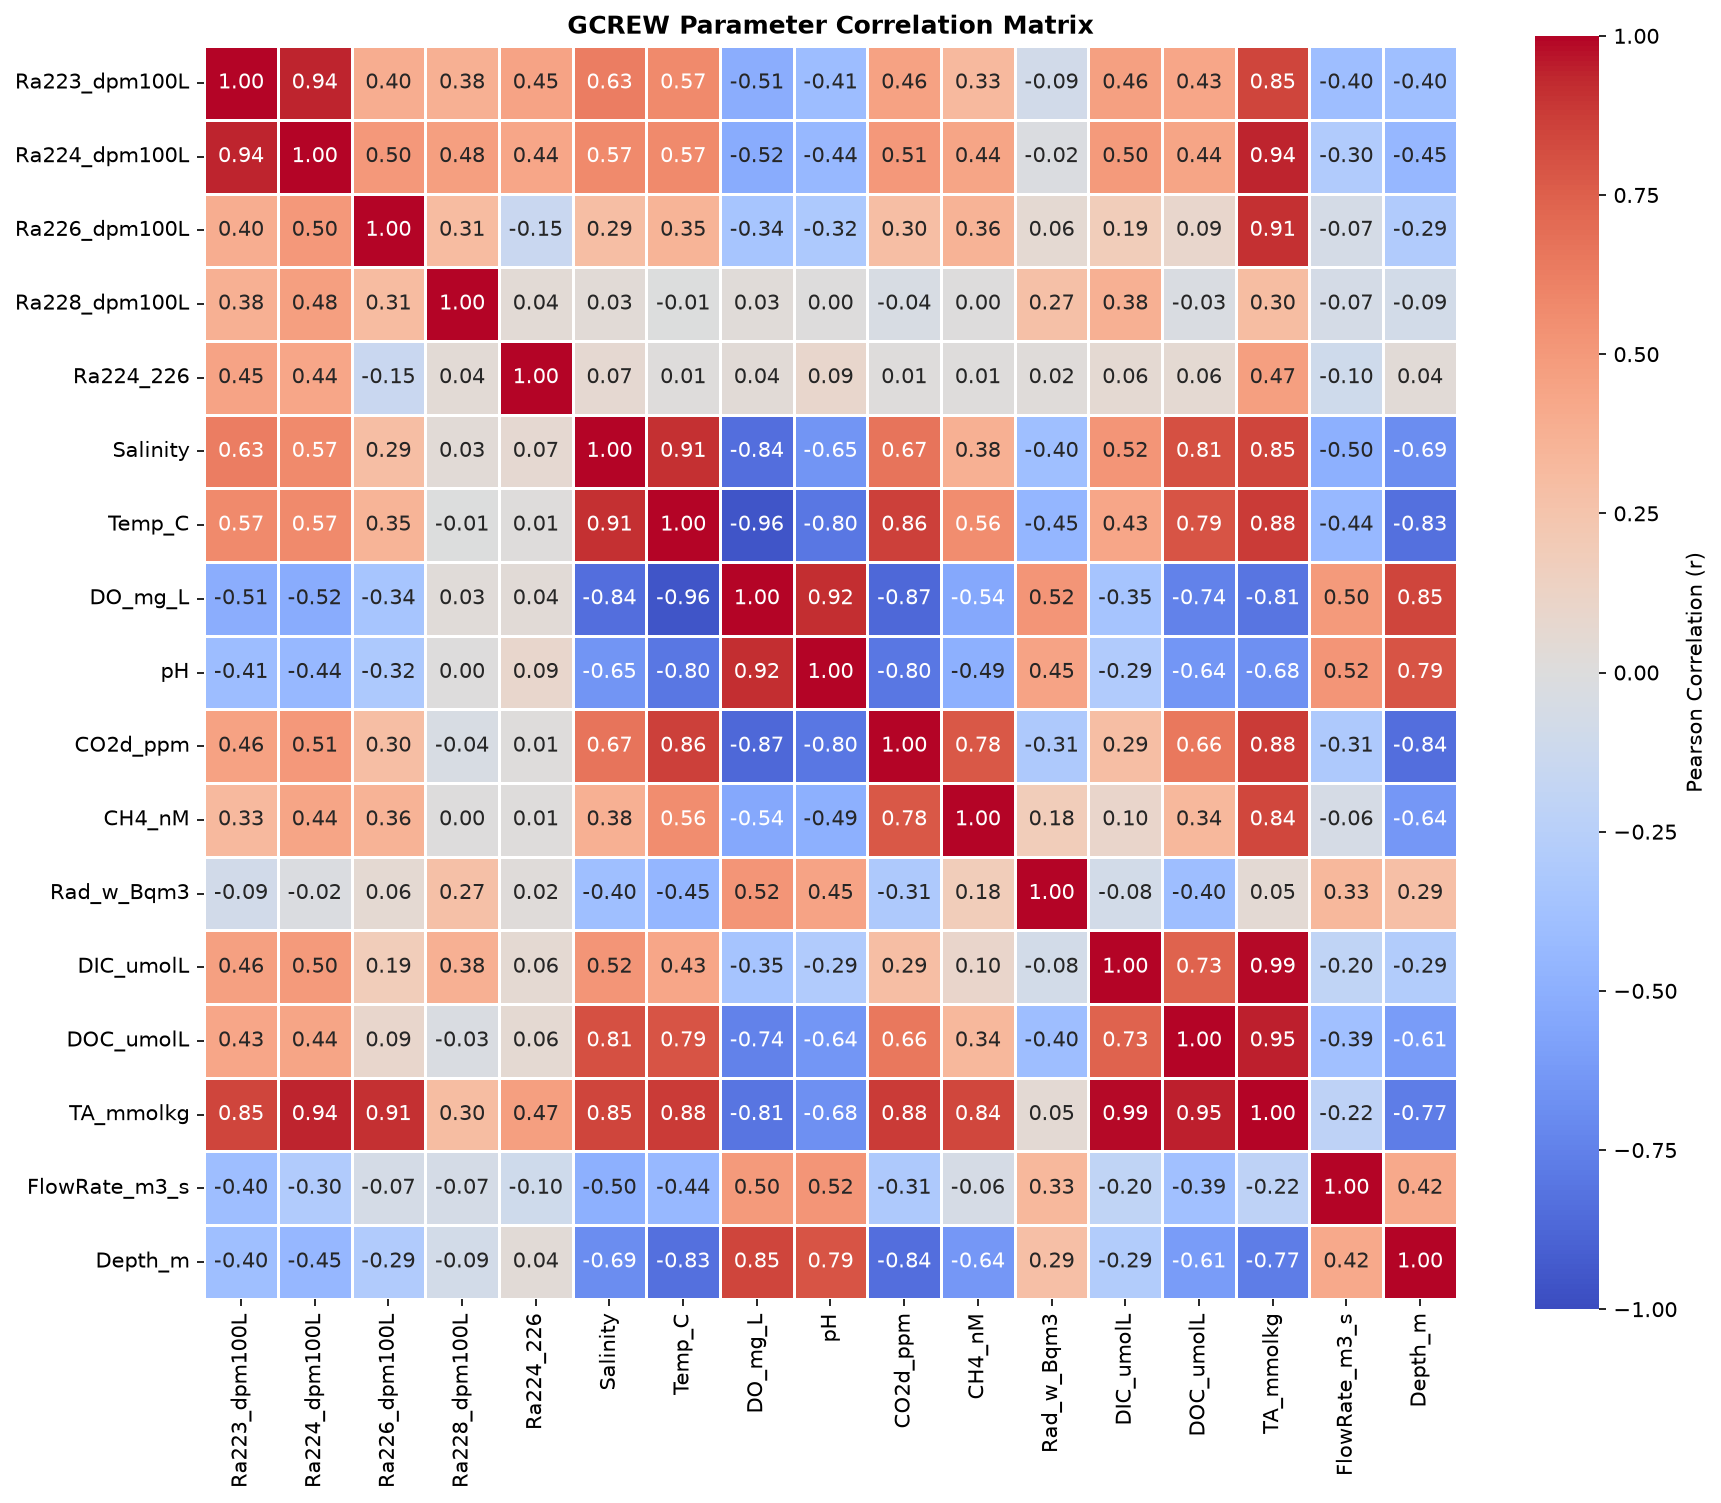

In [49]:
# calculate correlation matrix for key variables at GCREW
gcrew_corr = data_gcrew[gcrew_vars].corr(numeric_only=True) # compute linear correlation coefficients

# plot visual correlation matrix heatmap
plt.figure(figsize=(12, 10), dpi=150) 

# draw heatmap with colorbar and values formatted to 2 decimal places
sns.heatmap(gcrew_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation (r)'}) 

plt.title('GCREW Parameter Correlation Matrix', fontsize=12, fontweight='bold') 
plt.tight_layout() 
plt.show() 

The short-lived isotopes (Ra223, Ra224) are positively correlated with salinity, as I predicted, considering ionic strength/desportion from salinity drives Ra release into solution. The long-lived isotopes (Ra226, Ra228) are not correlated with salinity, likely since their distribution is dominated by deeper groundwater inputs as opposed to localized, rapid flushing and desorption. It's great to see how highly correlated Ra223, 224, and 226 are with total alkalinity because this indicates that PEX and SGD are the primary source of total alkalinity to the creek water. I also notice that TA is positively correlated with salinity and temperature, which tells me TA is seasonally variable, and CO2d and CH4, which tells me anaerobic respiration and methanogenesis within the marsh seds are producing greenhouse gases alongside alkalinity. The carbonate chemistry variables (DIC, DOC, TA) are very strongly correlated with eachother, which highlights microbial degradation of organic carbon driving metabolic respiration and releaseing DIC while generating TA.

I will select 4 variables of interest and make boxplots to analyze outliers and visualize the differences amongst water types.

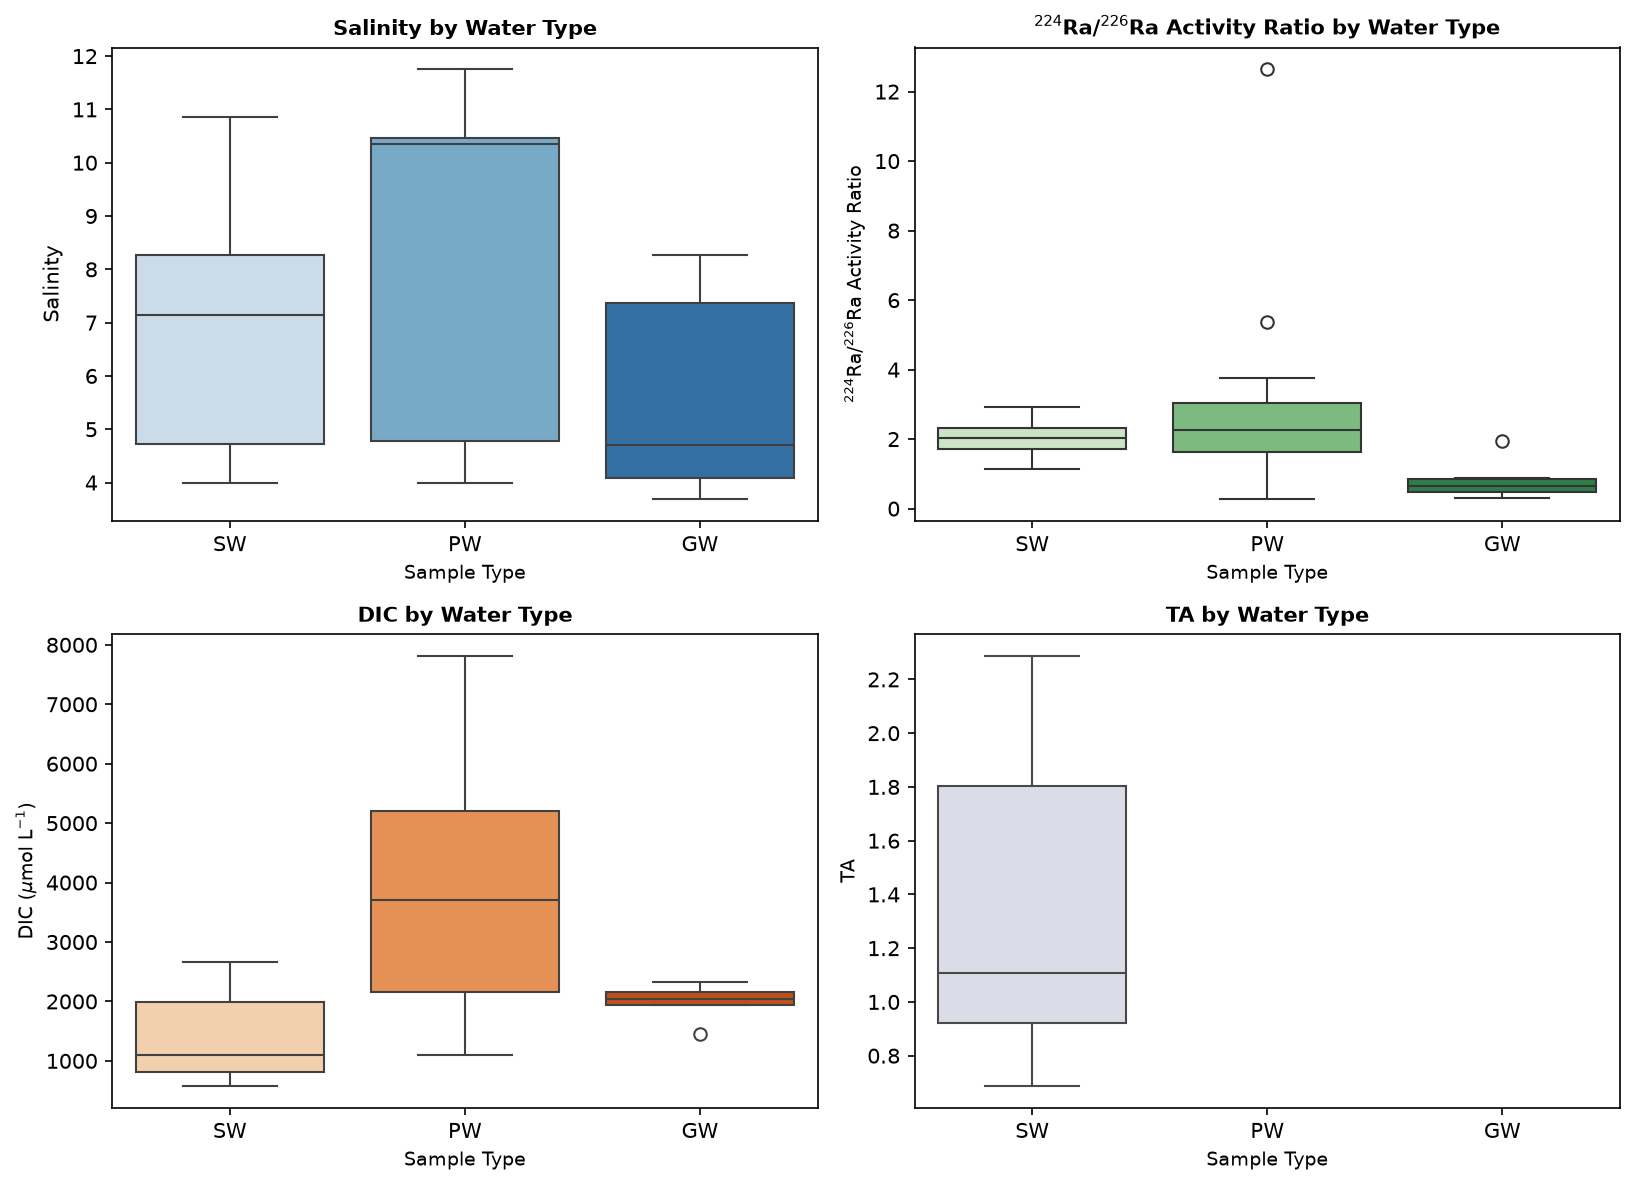

In [55]:
# create 2x2 grid of boxplots comparing parameters across Sample_Type (overall baseline)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=150)

# plot 1: Salinity across water types
sns.boxplot(data=data_gcrew, x='Sample_Type', y='Salinity', hue='Sample_Type', legend=False, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Salinity by Water Type', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Sample Type', fontsize=9)

# plot 2: Ra-224 / Ra-226 ratio across water types
sns.boxplot(data=data_gcrew, x='Sample_Type', y='Ra224_226', hue='Sample_Type', legend=False, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('$^{224}$Ra/$^{226}$Ra Activity Ratio by Water Type', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Sample Type', fontsize=9)
axes[0, 1].set_ylabel('$^{224}$Ra/$^{226}$Ra Activity Ratio', fontsize=9)

# plot 3: DIC across water types
sns.boxplot(data=data_gcrew, x='Sample_Type', y='DIC_umolL', hue='Sample_Type', legend=False, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('DIC by Water Type', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sample Type', fontsize=9)
axes[1, 0].set_ylabel(r'DIC ($\mu$mol L$^{-1}$)', fontsize=9) # added raw string r'...' to fix \mu warning

# plot 4: TA across water types
sns.boxplot(data=data_gcrew, x='Sample_Type', y=ta_col, hue='Sample_Type', legend=False, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('TA by Water Type', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Sample Type', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

The lines within the boxes are the medians and the box represents the middle 50% of the data. Looking at the activity ratio, the PW data likely contains 2 outliers and the GW data 1. An outlier in the GW data is also seen in the DIC plot, but is it the same sample ... unsure.

Next, I will start teasing apart seasonal and tidal variability.

In [37]:
# inspect unique values in Season and Tidal_Cycle columns
print("=== Unique Seasons in GCREW ===")
print(data_gcrew['Season'].unique()) 

print("\n=== Unique Tidal Cycles in GCREW ===") 
print(data_gcrew['Tidal_Cycle'].unique()) 

# cross-tabulate sample counts across Season, Tidal_Cycle, and Sample_Type
print("\n=== Sample Counts by Season, Tidal Cycle, and Sample Type ===") 
gcrew_counts = pd.crosstab(
    index=[data_gcrew['Season'], data_gcrew['Tidal_Cycle']], # row categories
    columns=data_gcrew['Sample_Type'] # column categories
) 

display(gcrew_counts) 

=== Unique Seasons in GCREW ===
<StringArray>
['Summer 2023', 'Winter 2024']
Length: 2, dtype: str

=== Unique Tidal Cycles in GCREW ===
<StringArray>
['neap', 'spring']
Length: 2, dtype: str

=== Sample Counts by Season, Tidal Cycle, and Sample Type ===


Sample_Type              GW  PW  SW
Season      Tidal_Cycle            
Summer 2023 neap          0   6  13
            spring        2   6  13
Winter 2024 neap          0   5  13
            spring        4   4  12

There were 2 GW and 12 PW samples collected in summer and 4 GW and 9 PW samplescollected in winter. There were 13 SW samples collected during each time series, with the exception of only 12 SW samples collected during the spring tide in the winter. I need to keep in mind that we are only interested in comparing SW when analyzing tidal variability. PW and GW respond more heavily to seasonal hydraulic gradients than tides.

In [50]:
# group by Sample_Type and Season 
gcrew_breakdown = data_gcrew.groupby(['Sample_Type', 'Season'])[gcrew_vars].agg(['mean', 'std'])

# transpose so parameters are stacked vertically for clean reading
display(gcrew_breakdown.T)

Sample_Type                  GW                        PW               \
Season              Summer 2023  Winter 2024  Summer 2023  Winter 2024   
Ra223_dpm100L mean     7.950000     1.950000    10.558333     6.533333   
              std      6.576093     1.567376     6.791901     5.346027   
Ra224_dpm100L mean   125.900000    21.475000   117.233333    88.412500   
              std    106.631703    21.967002    76.838595    74.289519   
Ra226_dpm100L mean   267.000000    21.800000    47.950000    37.175000   
              std    230.941075    10.621048    21.162381    29.411404   
Ra228_dpm100L mean   113.000000    72.000000    80.583333   150.111111   
              std     65.053824    39.115214    41.462926   146.593353   
Ra224_226     mean     0.480000     0.980000     2.449167     3.410000   
              std      0.014142     0.700238     1.081736     3.943055   
Salinity      mean     8.265000     4.239250    10.964167     4.987778   
              std      0.011314     0.533699     0.696646     0.764986   
Temp_C        mean    26.104350     6.079950    27.633342     6.861367   
              std      0.012657     0.879356     0.437211     0.815275   
DO_mg_L       mean     0.080000    14.613250     0.763917    15.307556   
              std      0.000000     1.780268     0.354323     0.914788   
pH            mean     6.698500     8.131000     6.957750     8.526778   
              std      0.012021     0.730020     0.176483     0.419884   
CO2d_ppm      mean  8103.601198   416.511264  7896.326640   213.207636   
              std   3020.301869   281.904057  2295.514158   175.529966   
CH4_nM        mean  1142.564037    62.237434   241.695533    61.288207   
              std    813.587390     9.707467    52.232662     7.371595   
Rad_w_Bqm3    mean   129.457595   142.246431    80.801806   139.065120   
              std     10.197337     9.227062     7.291238    24.094996   
DIC_umolL     mean  1887.852801  2046.457414  4502.539339  3040.731182   
              std    617.563078   108.199956  1832.081424  1736.954328   
DOC_umolL     mean   281.075681   154.724836  4207.601365   398.662337   
              std    257.386633   120.542084  1797.396995   124.982076   
TA_mmolkg     mean          NaN          NaN          NaN          NaN   
              std           NaN          NaN          NaN          NaN   
FlowRate_m3_s mean    -0.028195     0.212941    -0.172600     0.026862   
              std      0.017331     0.330617     0.142144     0.152868   
Depth_m       mean     0.693950     1.309275     0.840158     1.325689   
              std      0.006718     0.177665     0.050249     0.254864   

Sample_Type                   SW              
Season               Summer 2023 Winter 2024  
Ra223_dpm100L mean      7.111538    1.928000  
              std       2.594660    0.785027  
Ra224_dpm100L mean     88.684615   22.248000  
              std      30.393837    6.451945  
Ra226_dpm100L mean     41.630769   12.386957  
              std      10.416132    2.100066  
Ra228_dpm100L mean     60.807692   44.640000  
              std      13.317715   29.790770  
Ra224_226     mean      2.100769    1.905652  
              std       0.386212    0.376839  
Salinity      mean      8.230115    4.918080  
              std       0.874551    0.780515  
Temp_C        mean     26.164496    6.240484  
              std       1.758647    1.806387  
DO_mg_L       mean      0.304346   13.798080  
              std       0.501500    2.013865  
pH            mean      6.853731    8.138280  
              std       0.152316    0.586099  
CO2d_ppm      mean  11763.476623  382.329100  
              std    4014.832138  298.296495  
CH4_nM        mean   1042.643527   56.822302  
              std     895.283830   13.464423  
Rad_w_Bqm3    mean     95.793474  118.640878  
              std      37.759734   25.999717  
DIC_umolL     mean   1915.391660  801.761718  
              std     433.595636   61.385260  
DOC_umolL     mean 

The table above separates water type and season and the table below separates tidal cycles by season for SW only.

All Ra isotopes were higher in the summer than the winter in all water types, with the exception of Ra228 in PW and SW, specifically during the spring tide. 224/226Ra was highest in the winter in GW and PW but lower in the winter in SW. Salinity and temperature were higher in all water types in the summer, but DO was an order of magnitude greater in the winter. pH was higher in the winter. CO2d and CH4 were higher in the summer but radon were higher in the winter. DIC and DOC were higher in the summer in all water types, with the exception of DIC in GW in the winter. Flowrate was higher in the winter for all sample types, although I need to ask Joe why there are flow rate measurements for PW and GW... Water depth was higher in the tidal channel in the winter than the summer. 

In [51]:
# group by Sample_Type, Season, and Tidal_Cycle for SW only 
sw_data = data_gcrew[data_gcrew['Sample_Type'] == 'SW']
gcrew_breakdown = sw_data.groupby(['Sample_Type','Season','Tidal_Cycle'])[gcrew_vars].agg(['mean', 'std'])

# transpose so parameters are stacked vertically for clean reading
display(gcrew_breakdown.T)

Sample_Type                   SW                                      
Season               Summer 2023               Winter 2024            
Tidal_Cycle                 neap        spring        neap      spring
Ra223_dpm100L mean      5.384615      8.838462    1.584615    2.300000
              std       1.705797      2.157367    0.703380    0.717318
Ra224_dpm100L mean     71.200000    106.169231   18.446154   26.366667
              std      25.205886     25.036786    5.409038    4.828953
Ra226_dpm100L mean     35.576923     47.684615   11.463636   13.233333
              std      10.026395      6.789556    0.703239    2.595567
Ra228_dpm100L mean     61.000000     60.615385   18.538462   72.916667
              std      13.723459     13.456959    4.332347   15.441728
Ra224_226     mean      1.982308      2.219231    1.762727    2.036667
              std       0.307169      0.431267    0.298499    0.404797
Salinity      mean      7.767846      8.692385    4.439154    5.436917
              std       0.536883      0.917698    0.299932    0.816270
Temp_C        mean     25.784300     26.544692    5.458677    7.087442
              std       1.565224      1.918411    2.025796    1.066546
DO_mg_L       mean      0.129000      0.479692   14.532077   13.002917
              std       0.095783      0.669456    1.431295    2.299430
pH            mean      6.869769      6.837692    8.189077    8.083250
              std       0.038164      0.215221    0.639291    0.545235
CO2d_ppm      mean  11625.103821  11913.380491  376.454369  388.693393
              std    3206.787425   4889.066260  362.886644  224.492126
CH4_nM        mean    836.534317   1265.928504   47.476160   66.947290
              std     975.071626    779.107409    9.060539    9.535184
Rad_w_Bqm3    mean     70.278177    121.308771  110.580623  127.372821
              std      32.794187     22.008792   18.863646   30.442283
DIC_umolL     mean   1732.194207   2098.589114  798.345107  805.463048
              std     415.961578    382.017341   67.988316   56.125283
DOC_umolL     mean   2181.461865   2512.760739  283.912824  311.313114
              std     366.701209    387.092065   20.303063   26.412684
TA_mmolkg     mean      1.572096      1.928246    0.954329    0.888971
              std       0.322003      0.287812    0.075928    0.123313
FlowRate_m3_s mean     -0.061724     -0.050173    0.081186    0.021671
              std       0.045162      0.062735    0.191404    0.130225
Depth_m       mean      0.529008      0.800762    1.398577    1.191000
              std       0.231159      0.103979    0.136574    0.135074

All Ra isotopes and 224/226 were higher during the spring tide than the neap tide the same season, with the exception of Ra228 during the summer (but very small difference). Salinity and temperature were slightly higher during spring tides both seasons. DO was higher during spring tide in the summer and vice versa in the winter. pH was slightly higher during neap tide. CO2d, CH4, radon, DIC, DOC, and TA were all higher during spring tide, with the exception of neap tide during the winter. Flow rate and depth were higher during spring tide in the summer, but higher during neap tide in the winter.

Next steps as I move forward with the project would be to determine if there are significant differences between seasons and tidal cycles. 

I will create boxplots using the same variables as before but now parsed out to see seasonal differences.

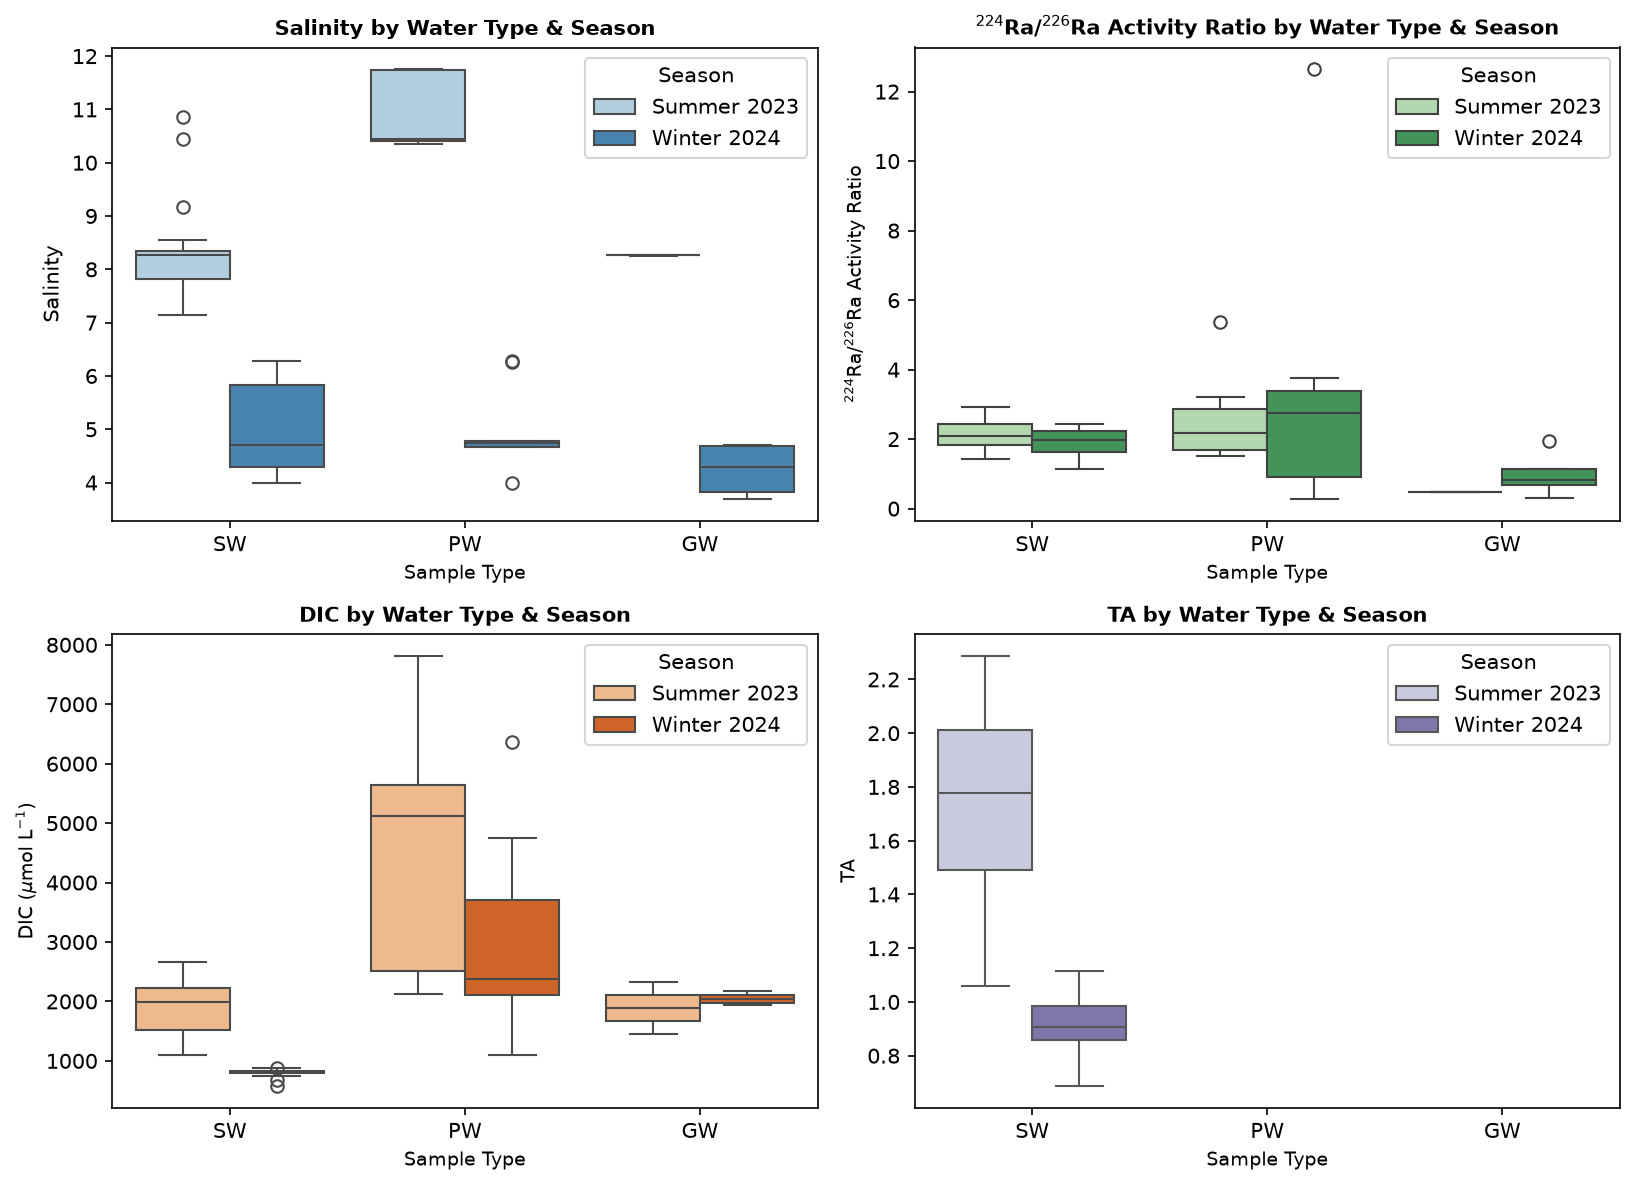

In [57]:
# create 2x2 grid of boxplots comparing Season across Sample_Type
fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=150)

# plot 1: Salinity
sns.boxplot(data=data_gcrew, x='Sample_Type', y='Salinity', hue='Season', ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Salinity by Water Type & Season', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Sample Type', fontsize=9)

# plot 2: Ra-224 / Ra-226 ratio
sns.boxplot(data=data_gcrew, x='Sample_Type', y='Ra224_226', hue='Season', ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('$^{224}$Ra/$^{226}$Ra Activity Ratio by Water Type & Season', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Sample Type', fontsize=9)
axes[0, 1].set_ylabel('$^{224}$Ra/$^{226}$Ra Activity Ratio', fontsize=9)

# plot 3: DIC (using r'...' raw string to prevent \mu syntax warning)
sns.boxplot(data=data_gcrew, x='Sample_Type', y='DIC_umolL', hue='Season', ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('DIC by Water Type & Season', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sample Type', fontsize=9)
axes[1, 0].set_ylabel(r'DIC ($\mu$mol L$^{-1}$)', fontsize=9)

# plot 4: TA
sns.boxplot(data=data_gcrew, x='Sample_Type', y=ta_col, hue='Season', ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('TA by Water Type & Season', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Sample Type', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

Salinity appears to be statistically different between summer and winter (error bars do not overlap). DIC in SW may also be statistically different between seasons. 

I will make one more figure to visually see the temporal differences in SW.

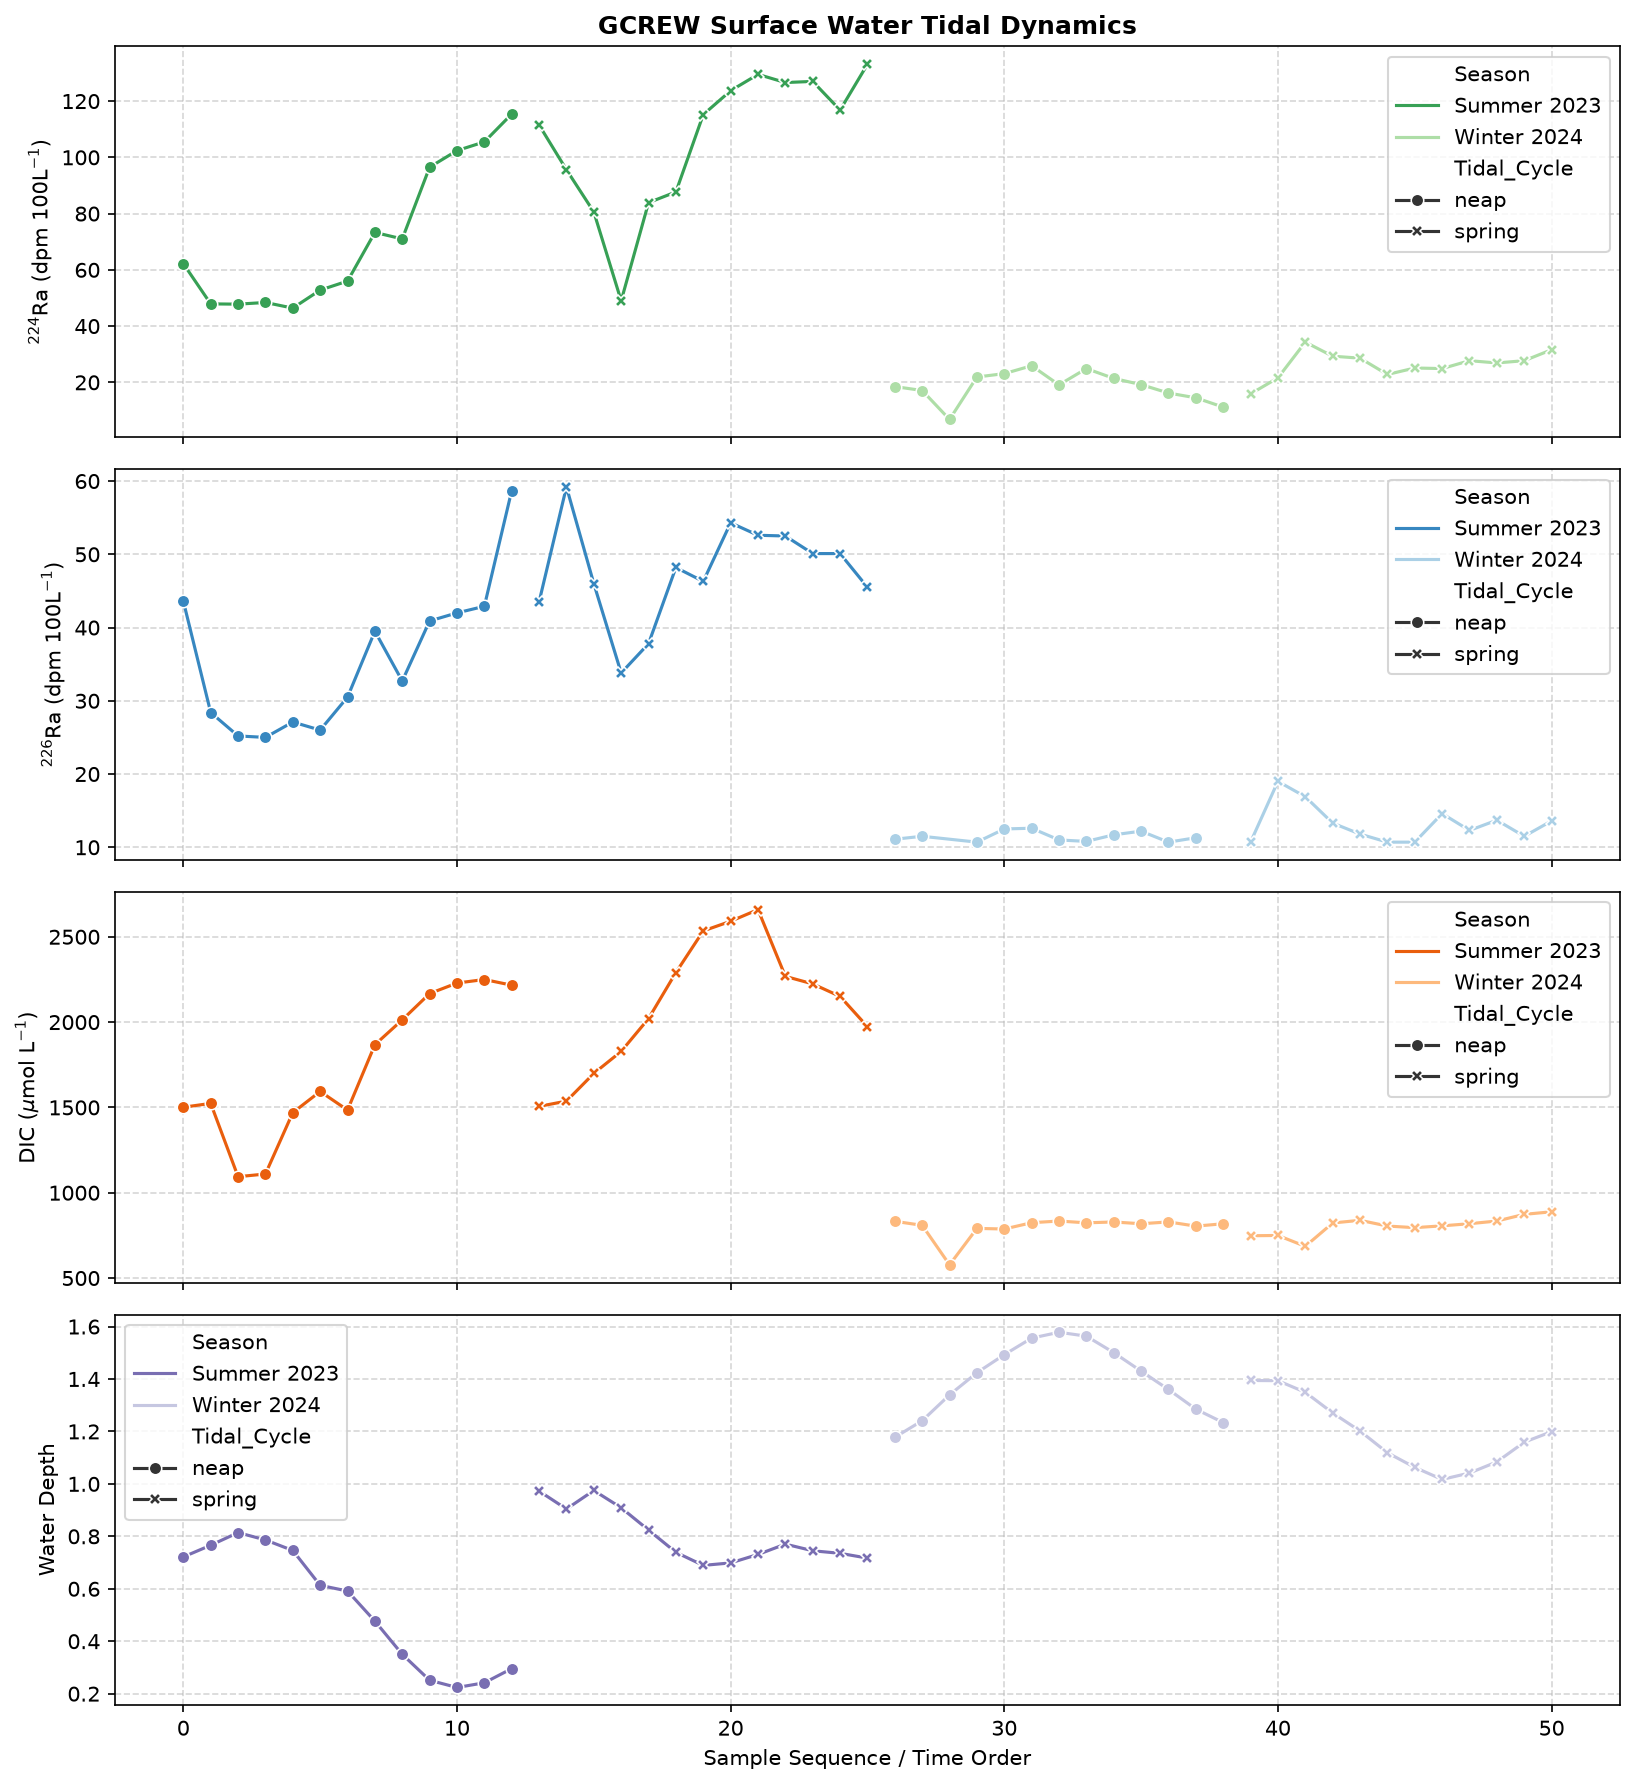

In [63]:
# filter for Surface Water only
sw_only = data_gcrew[data_gcrew['Sample_Type'] == 'SW'].copy()

# create 4-panel stacked time-series plot
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True, dpi=150)

# plot 1: Ra-224 over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='Ra224_dpm100L', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[0], palette='Greens_r')
axes[0].set_title('GCREW Surface Water Tidal Dynamics', fontsize=12, fontweight='bold')
axes[0].set_ylabel(r'$^{224}$Ra (dpm 100L$^{-1}$)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# plot 2: Ra-226 over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='Ra226_dpm100L', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[1], palette='Blues_r')
axes[1].set_ylabel(r'$^{226}$Ra (dpm 100L$^{-1}$)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

# plot 3: DIC over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='DIC_umolL', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[2], palette='Oranges_r')
axes[2].set_ylabel(r'DIC ($\mu$mol L$^{-1}$)', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.5)

# plot 4: Water Depth over Tidal Cycle (Tidal Stage Indicator)
sns.lineplot(data=sw_only, x=sw_only.index, y='Depth_m', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[3], palette='Purples_r')
axes[3].set_ylabel('Water Depth', fontsize=10)
axes[3].set_xlabel('Sample Sequence / Time Order', fontsize=10)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

We can see how much lower Ra224, Ra226, and DIC are in the winter compared to the summer, potentially due to the higher water depth we see in the winter. Higher water depth diminishes the hydraulic gradient, and thus the release of radium and other constituents from PW/GW to the channel.  

Conclusions for GCREW EDA: There are differences between summer and winter and likely differences between spring and neap. I need to play around with the data more to find trends and do statistics. 

TASK EDA: this dataset has time series data for all four seasons but no tidal cycle data.

In [66]:
# set pandas display option to show all columns
pd.set_option('display.max_rows', None)

# select key parameters to analyze 
task_vars = [
    'Ra223_dpm100L', 'Ra224_dpm100L', 'Ra226_dpm100L', 'Ra228_dpm100L', 'Ra224_226',
    'Salinity', 'Temp_C', 'DO_mg_L', 'pH',
    'TA_mmolkg','Si_uM','Depth_m'
] 

# calculate all descriptive stats grouped by Sample_Type
task_endmember_stats = data_task.groupby('Sample_Type')[task_vars].describe() 

# transpose the table so parameters are rows and statistics are readable columns
task_endmember_stats_formatted = task_endmember_stats.T

# display the complete summary table
display(task_endmember_stats_formatted) 

Sample_Type                  GW          PW          SW
Ra223_dpm100L count    5.000000    2.000000  128.000000
              mean     9.920000   14.450000    3.192188
              std      6.395076    3.181981    1.438153
              min      1.600000   12.200000    0.400000
              25%      8.400000   13.325000    2.200000
              50%      8.500000   14.450000    3.200000
              75%     11.900000   15.575000    4.100000
              max     19.200000   16.700000    8.500000
Ra224_dpm100L count    5.000000    2.000000  129.000000
              mean   154.260000  226.950000   70.365116
              std     83.410869   17.465537   22.564891
              min     47.200000  214.600000   10.500000
              25%     90.300000  220.775000   61.800000
              50%    184.100000  226.950000   72.900000
              75%    198.200000  233.125000   86.500000
              max    251.500000  239.300000  113.700000
Ra226_dpm100L count    5.000000    2.000000  129.000000
              mean   155.100000   48.800000   29.043411
              std     61.269527    1.555635   10.680406
              min     50.900000   47.700000    8.200000
              25%    153.000000   48.250000   22.400000
              50%    181.000000   48.800000   27.500000
              75%    184.100000   49.350000   36.500000
              max    206.500000   49.900000   56.200000
Ra228_dpm100L count    5.000000    2.000000  129.000000
              mean   150.800000  216.600000   69.944961
              std     71.906849    2.969848   25.763952
              min     54.900000  214.500000   14.100000
              25%     92.900000  215.550000   55.900000
              50%    190.400000  216.600000   73.000000
              75%    203.200000  217.650000   88.000000
              max    212.600000  218.700000  118.700000
Ra224_226     count    5.000000    2.000000  129.000000
              mean     0.966000    4.645000    2.489070
              std      0.236495    0.205061    0.657277
              min      0.590000    4.500000    0.800000
              25%      0.930000    4.572500    2.140000
              50%      1.000000    4.645000    2.460000
              75%      1.090000    4.717500    3.000000
              max      1.220000    4.790000    4.180000
Salinity      count    4.000000    2.000000  129.000000
              mean     3.082500   16.785000   13.601860
              std      3.083530    0.657609    8.580220
              min      1.000000   16.320000    1.520000
              25%      1.585000   16.552500    8.370000
              50%      1.830000   16.785000   10.260000
              75%      3.327500   17.017500   16.490000
              max      7.670000   17.250000   32.350000
Temp_C        count    4.000000    2.000000  129.000000
              mean    17.127500   19.860000   21.305364
              std      7.740049    3.323402    6.536091
              min      5.580000   17.510000    5.360000
              25%     16.425000   18.685000   17.570000
              50%     20.465000   19.860000   22.710000
              75%     21.167500   21.035000   25.035000
              max     22.000000   22.210000   32.350000
DO_mg_L       count    4.000000    0.000000  129.000000
              mean     5.517500         NaN    7.966124
              std      3.122695         NaN    2.258016
              min      1.800000         NaN    3.430000
              25%      3.600000         NaN    6.430000
              50%      5.760000         NaN    7.670000
              75%      7.677500         NaN    9.790000
              max      8.750000         NaN   14.770000
pH            count    5.000000    2.000000  129.000000
              mean     6.464000    5.010000    7.969535
              std      0.328451    2.177889    0.573198
              min      5.970000    3.470000    7.110000
              25%      6.380000    4.240000    7.490000
              50%      6.450000    5.010000    7.900000
              75%      6

On average, PW had the highest activities of the short-lived isotopes (Ra223, Ra224) and Ra228, but GW had the highest activities of Ra226, similar to GCREW. PW also had the highest 224/226Ra. For water quality parameters, PW had the highest salinity, and SW had the highest temperatures, dissolved oxygen, and pH (note no DO for PW). PW had the highest TA and silica concentrations. 

It is important to note that there are only 2 PW samples taken across all seasons but 128 SW. I am skeptical that one of these 2 samples will be my PW endmember. Additional PW sampling is taking place soon. 

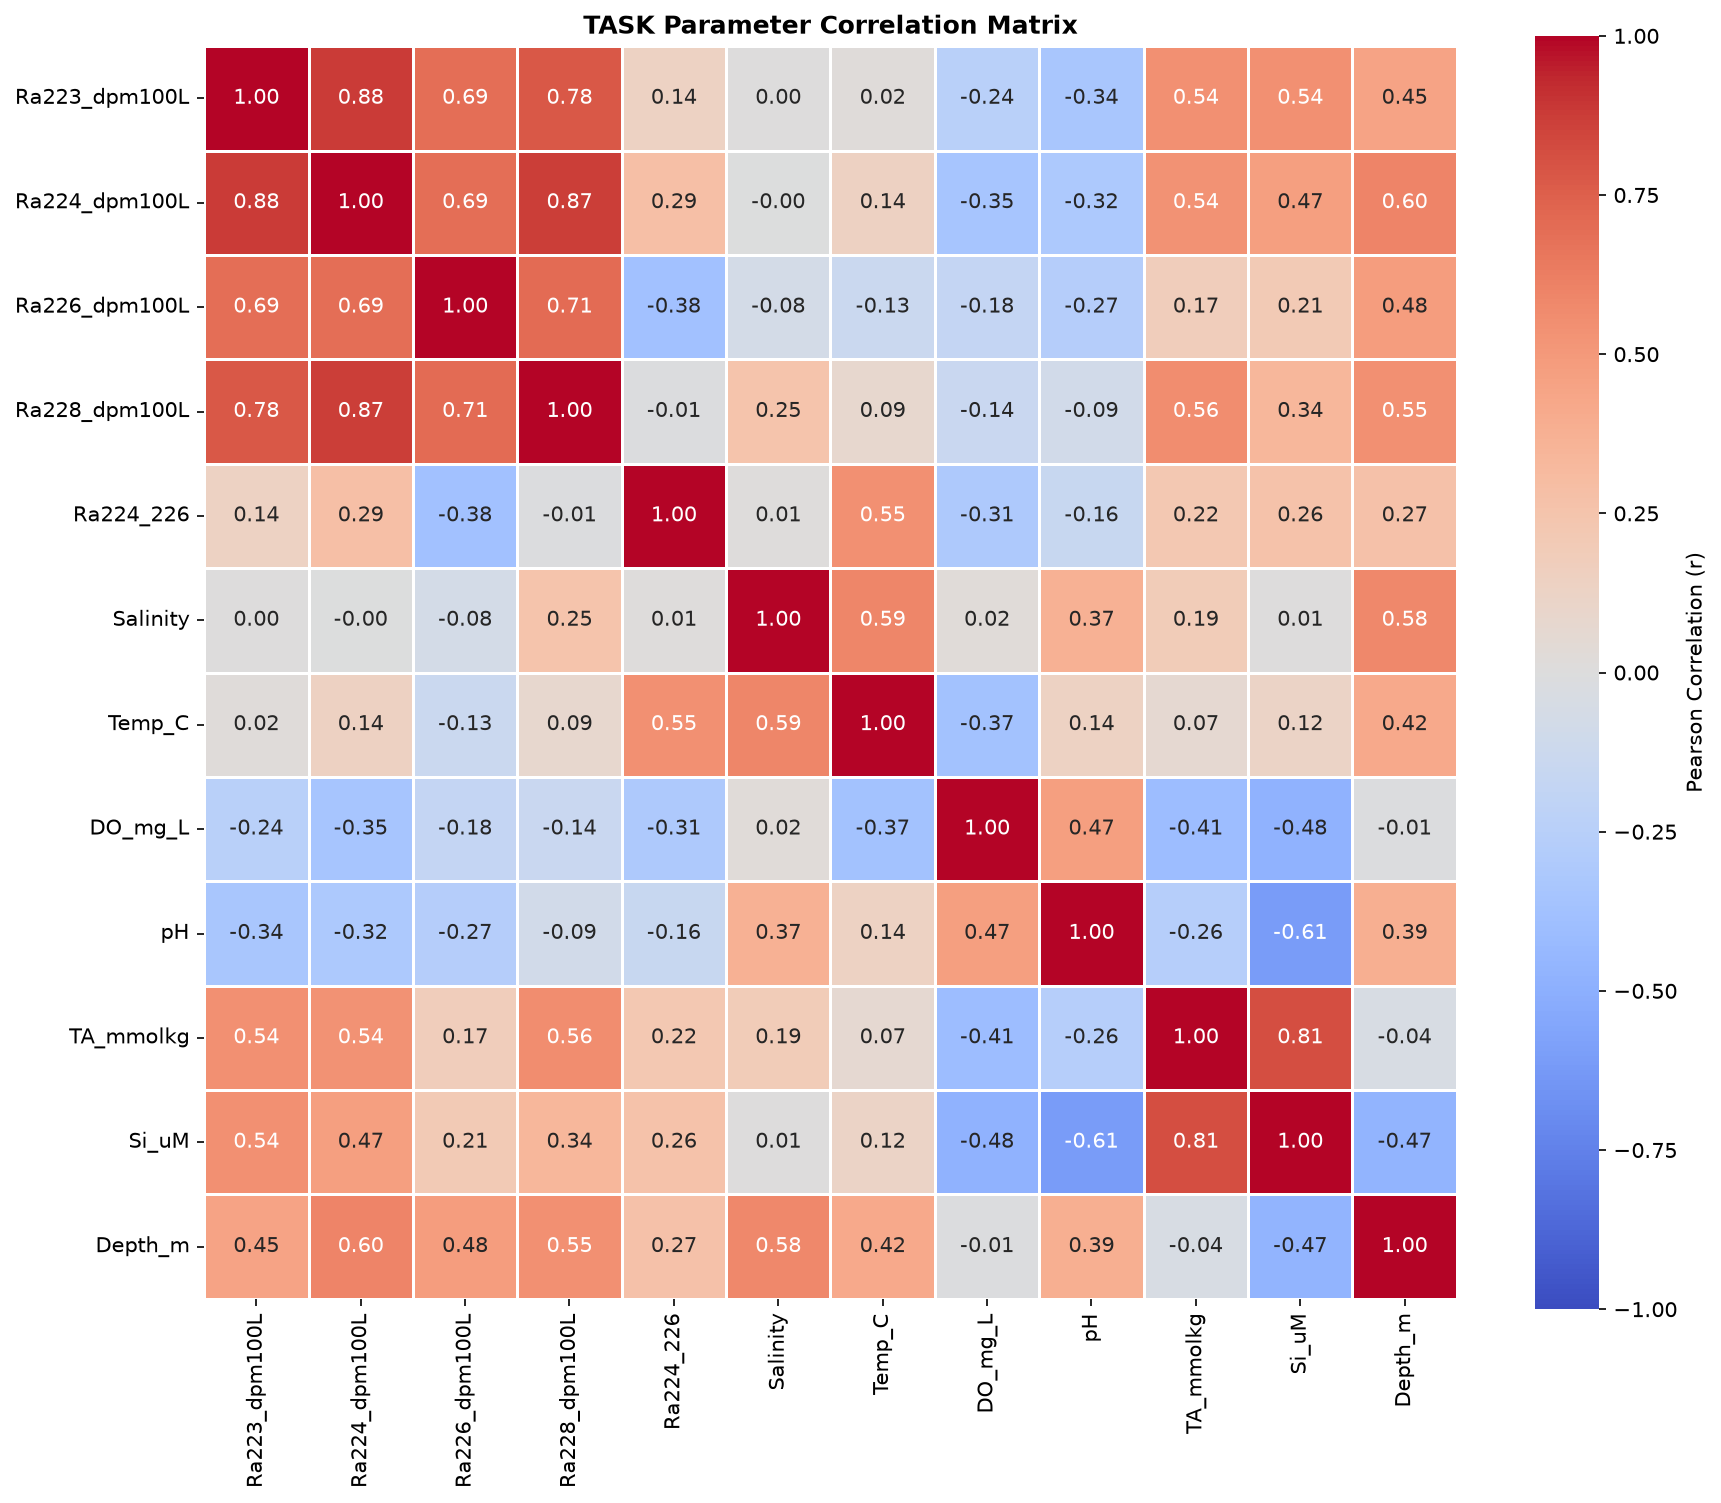

In [67]:
# calculate correlation matrix for key variables at TASK
task_corr = data_task[task_vars].corr(numeric_only=True) # compute linear correlation coefficients

# plot visual correlation matrix heatmap
plt.figure(figsize=(12, 10), dpi=150) 

# draw heatmap with colorbar and values formatted to 2 decimal places
sns.heatmap(task_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation (r)'}) 

plt.title('TASK Parameter Correlation Matrix', fontsize=12, fontweight='bold') 
plt.tight_layout() 
plt.show() 

There is a striking correlation between all radium isotopes. The only other eye catching correlation is Si and TA, which is great because both are a shared, sediment derived source to the creek and thus serve as co-tracers for PEX and SGD.

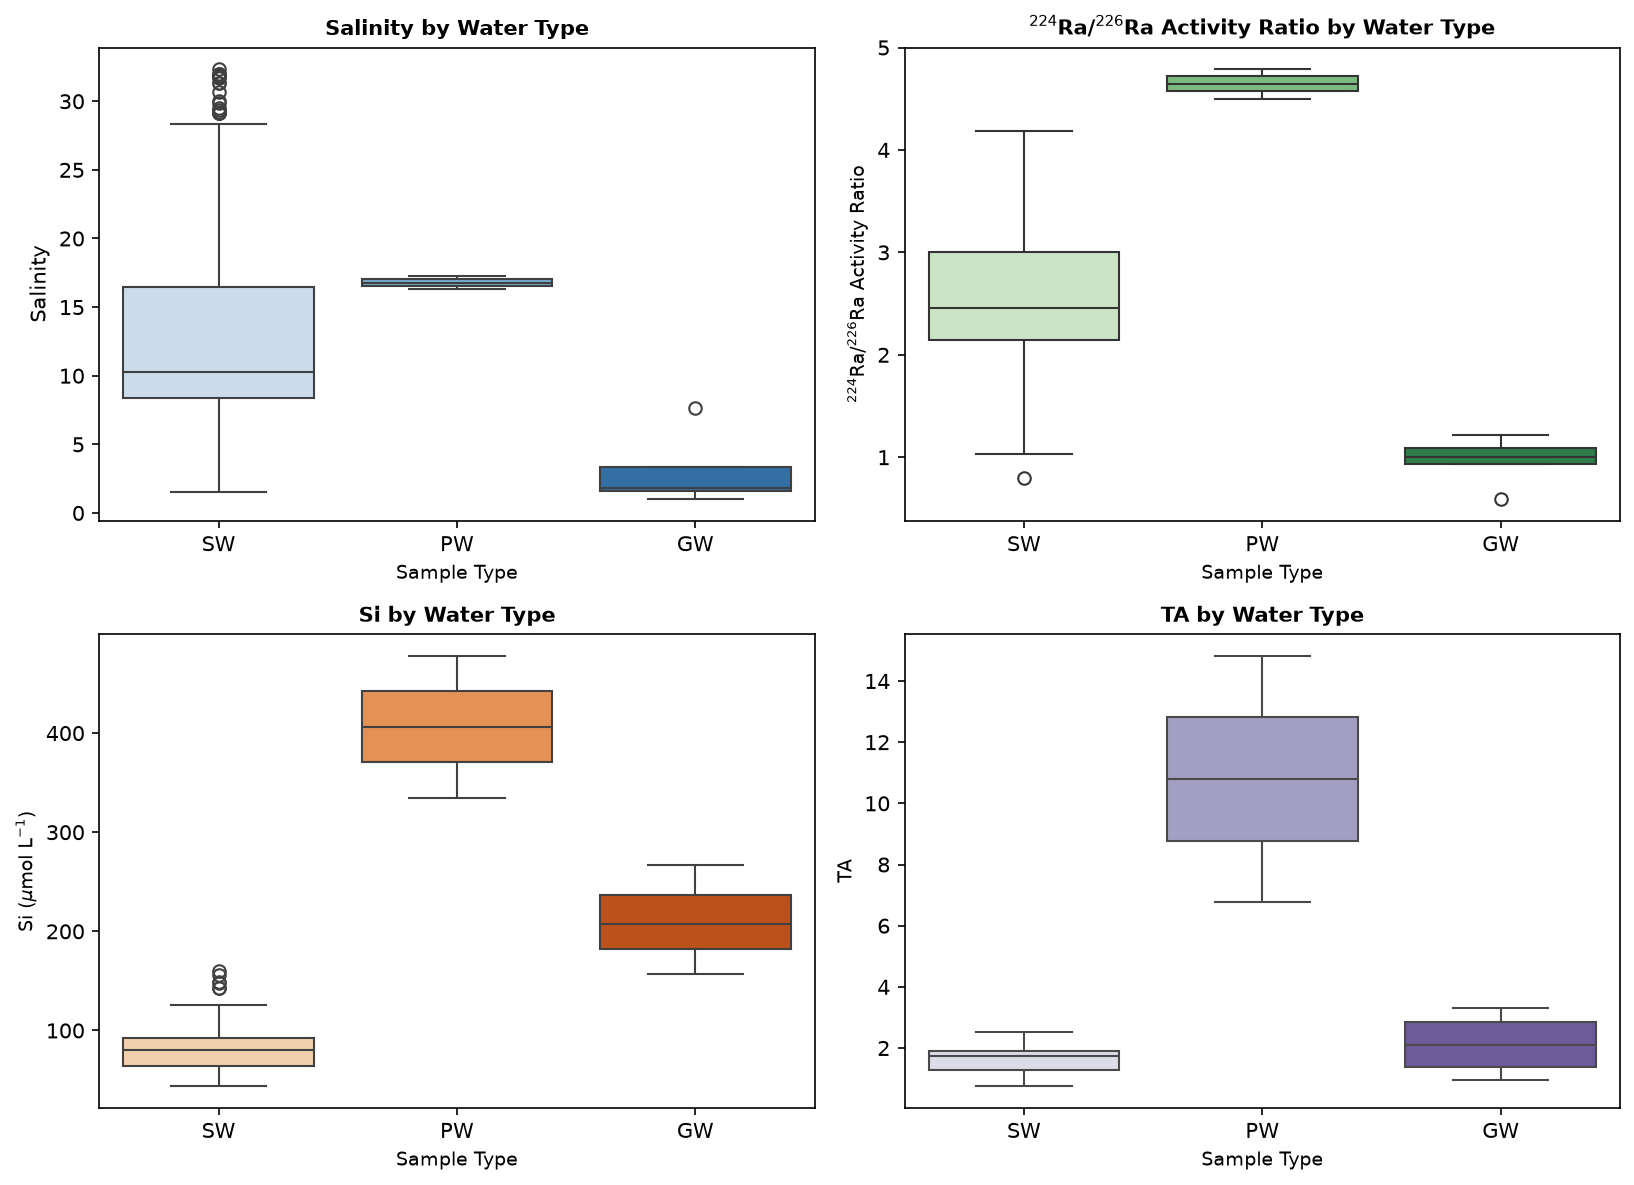

In [68]:
# create 2x2 grid of boxplots comparing parameters across Sample_Type (overall baseline)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=150)

# plot 1: Salinity across water types
sns.boxplot(data=data_task, x='Sample_Type', y='Salinity', hue='Sample_Type', legend=False, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Salinity by Water Type', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Sample Type', fontsize=9)

# plot 2: Ra-224 / Ra-226 ratio across water types
sns.boxplot(data=data_task, x='Sample_Type', y='Ra224_226', hue='Sample_Type', legend=False, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('$^{224}$Ra/$^{226}$Ra Activity Ratio by Water Type', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Sample Type', fontsize=9)
axes[0, 1].set_ylabel('$^{224}$Ra/$^{226}$Ra Activity Ratio', fontsize=9)

# plot 3: Si across water types
sns.boxplot(data=data_task, x='Sample_Type', y='Si_uM', hue='Sample_Type', legend=False, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('Si by Water Type', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sample Type', fontsize=9)
axes[1, 0].set_ylabel(r'Si ($\mu$mol L$^{-1}$)', fontsize=9) # added raw string r'...' to fix \mu warning

# plot 4: TA across water types
sns.boxplot(data=data_task, x='Sample_Type', y=ta_col, hue='Sample_Type', legend=False, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('TA by Water Type', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Sample Type', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

The salinity data contains quite a few outliers for SW and one for GW. There looks to be a statistical difference between Ra ratio activity, Si, and TA in PW vs SW and GW. There may be a statistical difference between GW and SW Si. 

In [76]:
# inspect unique values in Season 
print("=== Unique Seasons in TASK ===")
print(data_task['Season'].unique())  

=== Unique Seasons in TASK ===
<StringArray>
[  'Fall 2023', 'Spring 2024', 'Summer 2024',   'Fall 2024', 'Winter 2025',
 'Spring 2025']
Length: 6, dtype: str


There are six time series measurments: 2 spring, 1 summer, 2 fall, 1 winter

In [73]:
# group by Sample_Type and Season 
task_breakdown = data_task.groupby(['Sample_Type', 'Season'])[task_vars].agg(['mean', 'std'])

# transpose so parameters are stacked vertically for clean reading
display(task_breakdown.T)

Sample_Type                 GW                                  PW         SW  \
Season               Fall 2024 Spring 2025 Winter 2025   Fall 2024  Fall 2023   
Ra223_dpm100L mean    5.000000    8.500000   15.550000   14.450000   3.404545   
              std     4.808326         NaN    5.161880    3.181981   0.823741   
Ra224_dpm100L mean   68.750000  198.200000  217.800000  226.950000  74.431818   
              std    30.476302         NaN   47.658997   17.465537  10.288384   
Ra226_dpm100L mean  101.950000  181.000000  195.300000   48.800000  43.277273   
              std    72.195602         NaN   15.839192    1.555635   7.601123   
Ra228_dpm100L mean   73.900000  203.200000  201.500000  216.600000  88.863636   
              std    26.870058         NaN   15.697771    2.969848   7.421304   
Ra224_226     mean    0.760000    1.090000    1.110000    4.645000   1.776364   
              std     0.240416         NaN    0.155563    0.205061   0.418860   
Salinity      mean    4.335000         NaN    1.830000   16.785000  15.484091   
              std     4.716402         NaN    0.070711    0.657609   1.627697   
Temp_C        mean   20.465000   22.000000    5.580000   19.860000  16.140000   
              std     0.601041         NaN         NaN    3.323402   1.250219   
DO_mg_L       mean    3.000000         NaN    8.035000         NaN   8.162727   
              std     1.697056         NaN    1.011163         NaN   1.820524   
pH            mean    6.760000    6.380000    6.210000    5.010000   7.935455   
              std     0.070711         NaN    0.339411    2.177889   0.214292   
TA_mmolkg     mean    2.685973    3.295482    1.234661   10.797177   2.036749   
              std          NaN         NaN    0.398236    5.698003   0.190868   
Si_uM         mean  212.000000  207.000000         NaN  406.500000  57.227273   
              std    77.781746         NaN         NaN  101.116270  12.455375   
Depth_m       mean         NaN         NaN         NaN         NaN   1.303636   
              std          NaN         NaN         NaN         NaN   0.301339   

Sample_Type                                                                    
Season              Fall 2024 Spring 2024 Spring 2025 Summer 2024 Winter 2025  
Ra223_dpm100L mean   4.287500    3.841667    2.633333    3.018182    0.750000  
              std    1.113675    1.823736    0.779446    0.665930    0.206706  
Ra224_dpm100L mean  90.075000   84.025000   68.741667   62.265217   14.941667  
              std    7.140165   18.293245    6.261610    4.656921    3.078801  
Ra226_dpm100L mean  38.312500   27.458333   21.845833   25.004348    9.716667  
              std    2.553993    3.051289    3.208952    2.023830    1.217175  
Ra228_dpm100L mean  99.454167   60.000000   55.412500   74.217391   17.008333  
              std   12.105334   14.820667    8.594250   12.317602    2.788763  
Ra224_226     mean   2.355833    3.043750    3.178333    2.500435    1.552500  
              std    0.182326    0.488483    0.288122    0.246198    0.330540  
Salinity      mean  12.550000    7.874583    7.757917   30.078261    3.817500  
              std    1.957987    1.220641    1.452763    1.595396    1.827309  
Temp_C        mean  19.527375   23.158333   24.685208   30.078261    7.050833  
              std    0.974991    1.631965    1.583600    1.595396    0.987278  
DO_mg_L       mean   8.560417    6.102500    7.201250    7.715217   12.155000  
              std    1.143676    0.624787    2.220980    1.948643    1.602308  
pH            mean   8.827500    7.400417    7.626667    8.210435    7.678333  
              std    0.377293    0.133139    0.324488    0.306809    0.454989  
TA_mmolkg     mean   1.952780    1.456528    1.402508    1.940168    1.002029  
              std    0.299339    0.233055    0.295472    0.284554    0.147781  
Si_uM         mean  65.458333   93.791667   85.375000   99.043478   87.083333  
              std   16.245345    7.253060   21.858861

GW samples were collected during 1 spring, 1 fall, and 1 winter season. PW samples were only collected during one fall campaign, and for this reason, I will only compare GW and SW here. All of the isotope activities were very low in SW in the winter, but were interestingly the highest in SW in the winter (with the exception of 228, which was higher in spring in GW). Salinity, temperature, and pH were higher in GW in the fall and higher (more basic) in SW in the summer (fall is second, keeping in mind there's no summer GW sample). TA was highest in GW in the spring and in SW in the fall. Si was highest in GW in the fall and SW in the summer. Water depth was lower in 2025 compared to previous seasons.

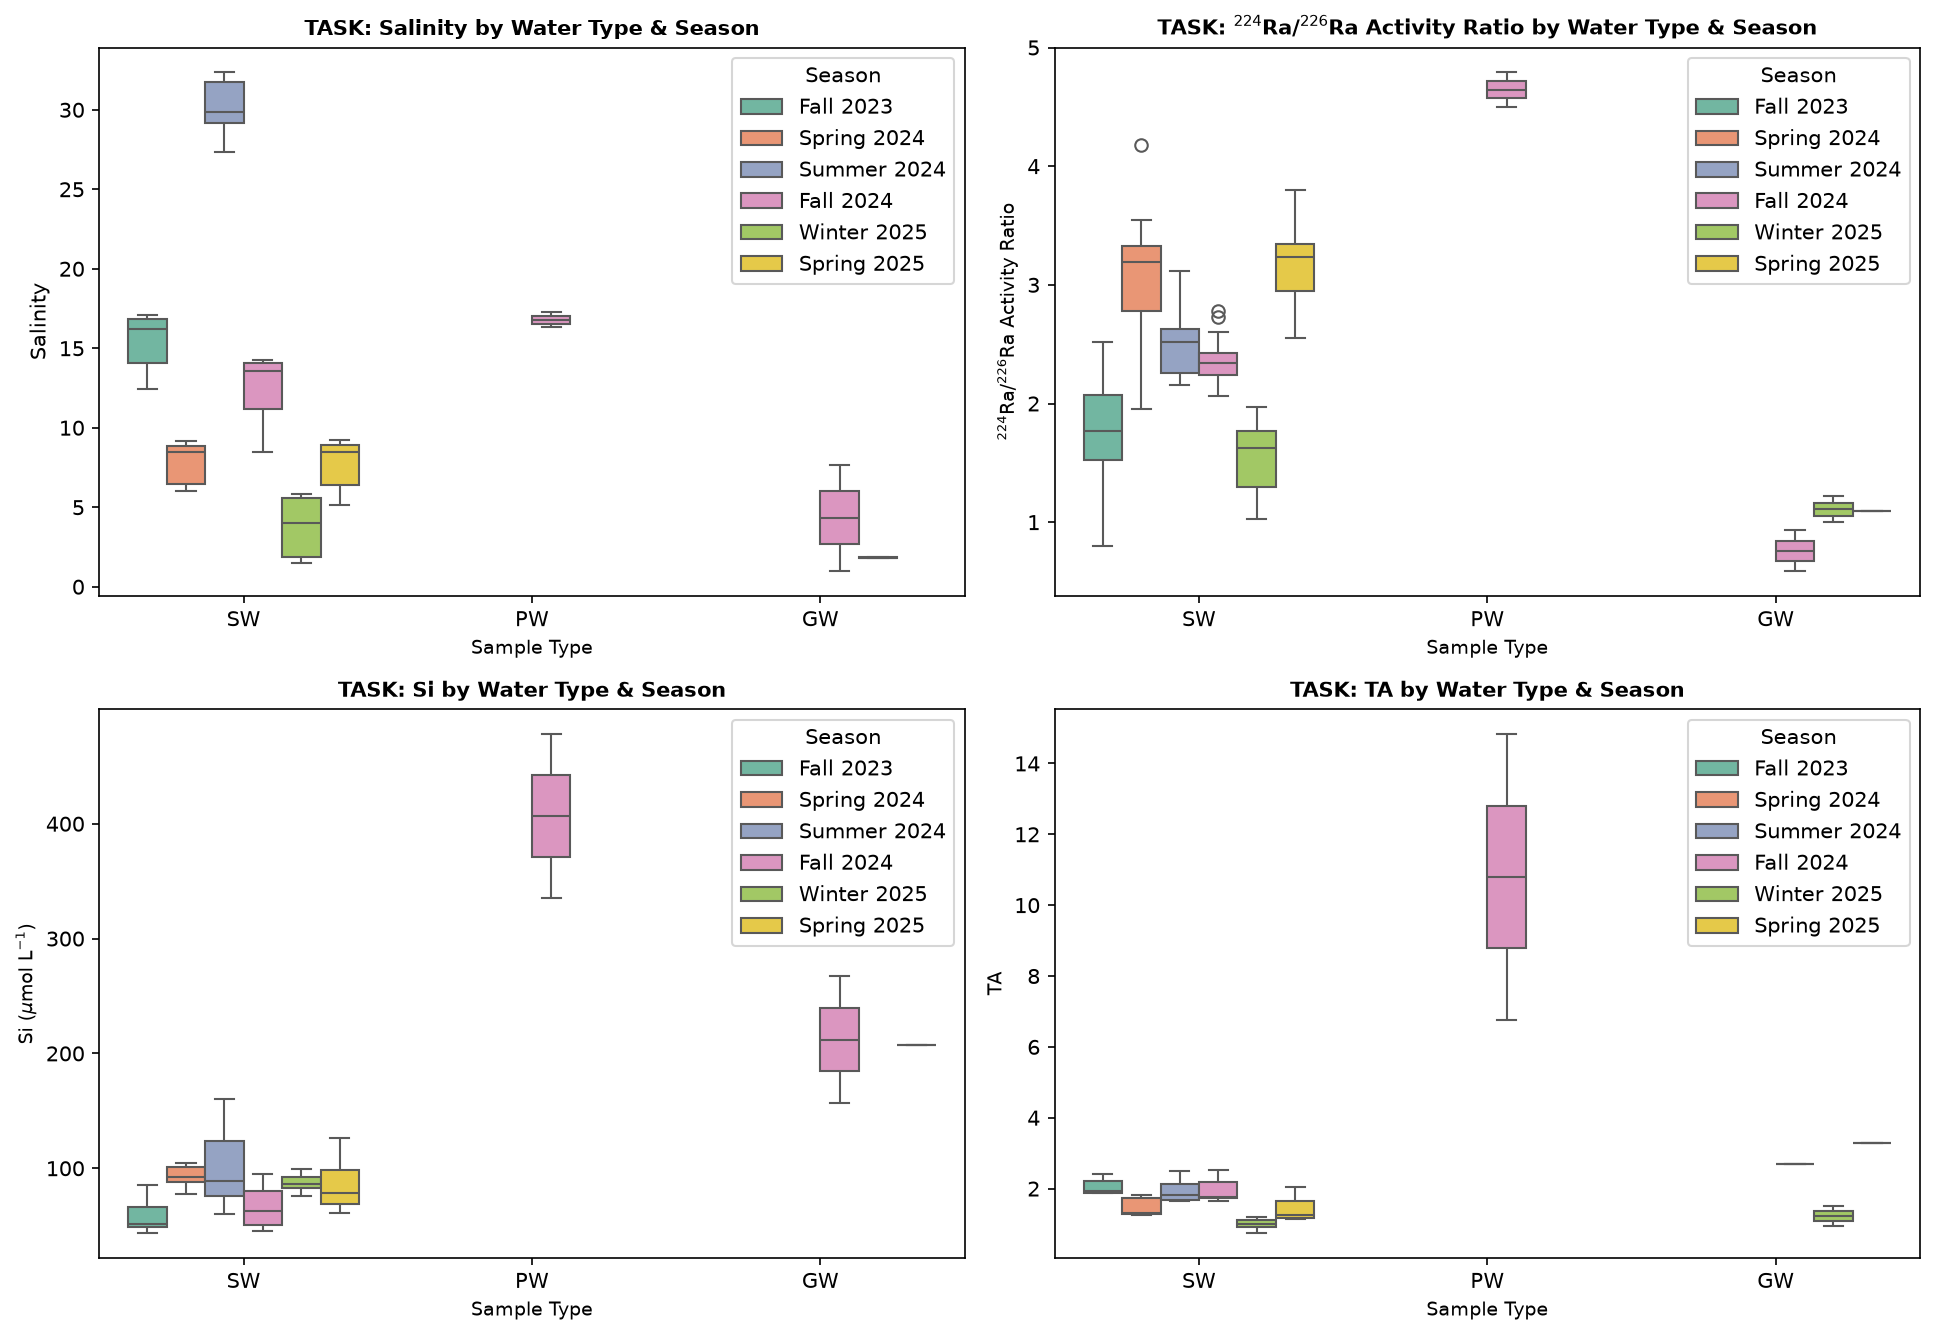

In [78]:
# create 2x2 grid of boxplots comparing all 6 Seasons across Sample_Type
fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=150)

# plot 1: Salinity
sns.boxplot(data=data_task, x='Sample_Type', y='Salinity', hue='Season', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('TASK: Salinity by Water Type & Season', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Sample Type', fontsize=9)

# plot 2: Ra-224 / Ra-226 Activity Ratio
sns.boxplot(data=data_task, x='Sample_Type', y='Ra224_226', hue='Season', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title(r'TASK: $^{224}$Ra/$^{226}$Ra Activity Ratio by Water Type & Season', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Sample Type', fontsize=9)
axes[0, 1].set_ylabel(r'$^{224}$Ra/$^{226}$Ra Activity Ratio', fontsize=9)

# plot 3: Si
sns.boxplot(data=data_task, x='Sample_Type', y='Si_uM', hue='Season', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('TASK: Si by Water Type & Season', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sample Type', fontsize=9)
axes[1, 0].set_ylabel(r'Si ($\mu$mol L$^{-1}$)', fontsize=9)

# plot 4: TA
sns.boxplot(data=data_task, x='Sample_Type', y=ta_col, hue='Season', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('TASK: TA by Water Type & Season', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Sample Type', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

This is a pretty fresh/ brackish tidal creek, but the salinity in the summer is strikingly higher in the summer than it is in the winter. Since we have Sw, GW, and PW samples from Fall 2024, it's cool to see that the Ra ratio, Si, and TA are significantly different between the three water types. Significant differences in Ra ratios between seasons would be justification for choosing seasonal endmembers. There appears to be differences between winter vs fall, summer, and spring, but maybe no differences amongst those seasons.

I will run statistics to ensure there are no significant differences amongst seasons (e.g. Spring 2024 and Spring 2025), but it looks like I will be able to group the seasons together.

I do not have depth data yet. This is a reminder to self to reach out to Ray.

FLSP EDA: this dataset will be structured very similarly to GCREW, except we do not have winter data yet. I'm still in the process of laboratory analyses and data cleaning for the summer campaign. 

In [80]:
# set pandas display option to show all columns
pd.set_option('display.max_rows', None)

# select key parameters to analyze 
flsp_vars = [
    'Ra223_dpm100L', 'Ra224_dpm100L', 'Ra226_dpm100L', 'Ra224_226',
    'Salinity', 'Temp_C', 'DO_mg_L', 'pH', 
    'fCO2_uatm', 'CH4_nM', 'TA_mmolkg',
    'Depth_m','Si_uM'
] 

# calculate all descriptive stats grouped by Sample_Type
flsp_endmember_stats = data_flsp.groupby('Sample_Type')[flsp_vars].describe() 

# transpose the table so parameters are rows and statistics are readable columns
flsp_endmember_stats_formatted = flsp_endmember_stats.T

# display the complete summary table
display(flsp_endmember_stats_formatted) 

Sample_Type                    GW            PW           SW
Ra223_dpm100L count      1.000000      9.000000    22.000000
              mean       1.218637      7.751777     7.180189
              std             NaN      6.020241     1.726517
              min        1.218637      0.114097     4.573133
              25%        1.218637      3.777254     5.857359
              50%        1.218637      7.248903     6.987768
              75%        1.218637      9.197952     8.732036
              max        1.218637     17.782109    10.145100
Ra224_dpm100L count      1.000000      9.000000    22.000000
              mean      18.089478    188.982037   127.419297
              std             NaN    124.302851    51.805866
              min       18.089478     32.090545    77.298703
              25%       18.089478     83.703760    83.707932
              50%       18.089478    227.531586   109.284924
              75%       18.089478    240.436241   160.206138
              max       18.089478    426.873376   236.951775
Ra226_dpm100L count      0.000000      0.000000    22.000000
              mean            NaN           NaN    37.872639
              std             NaN           NaN    13.074860
              min             NaN           NaN    25.009385
              25%             NaN           NaN    27.442890
              50%             NaN           NaN    31.817547
              75%             NaN           NaN    48.610228
              max             NaN           NaN    62.991269
Ra224_226     count      0.000000      0.000000    22.000000
              mean            NaN           NaN     3.335596
              std             NaN           NaN     0.499428
              min             NaN           NaN     2.068654
              25%             NaN           NaN     3.055051
              50%             NaN           NaN     3.401344
              75%             NaN           NaN     3.687490
              max             NaN           NaN     4.171474
Salinity      count      1.000000      9.000000    22.000000
              mean       0.120000     22.262889    26.697273
              std             NaN      7.208220     1.700048
              min        0.120000      5.256000    19.800000
              25%        0.120000     20.740000    26.677500
              50%        0.120000     24.960000    27.080000
              75%        0.120000     27.050000    27.537500
              max        0.120000     28.420000    28.110000
Temp_C        count      1.000000      9.000000    22.000000
              mean      24.350000     29.332222    33.707727
              std             NaN      2.982221     2.385192
              min       24.350000     26.040000    28.940000
              25%       24.350000     26.790000    31.852500
              50%       24.350000     28.650000    33.870000
              75%       24.350000     32.310000    35.292500
              max       24.350000     34.140000    37.220000
DO_mg_L       count      1.000000      9.000000    22.000000
              mean       3.254000      2.563000     4.846182
              std             NaN      0.650610     1.337322
              min        3.254000      2.052000     1.930000
              25%        3.254000      2.124000     4.332750
              50%        3.254000      2.271000     5.395000
              75%        3.254000      2.908000     5.673750
              max        3.254000      4.023000     6.440000
pH            count      1.000000      9.000000    22.000000
              mean       4.896000      6.565444     7.434318
              std             NaN      0.230888     0.374257
              min        4.896000      6.007000     6.640000
              25%        4.896000      6.569000     7.067500
              50%        4.896000      6.611000     7.600000
              75%        4.896000      6.706000     7.752250
              max        4.896000      6.801000     7.854000
fCO2_uatm     count      1.000000  

The short-lived isotopes are highest in PW. 226 and 228 in PW and GW will be analyzed within the next couple weeks. 228 in SW will be analyzed six months after sample collection (February 2027). We only collected one GW sample, but I feel hopeful we captured the GW endmember with a salinity of 0.12 and pH of 4.89. Salinity, temperature, DO, and pH were highest in SW. CO2 was highest in PW but CH4 was highest in SW. TA and Si were much higher in PW but we still see a good signature in the SW. TA for SW has an impressively low standard deviation. 

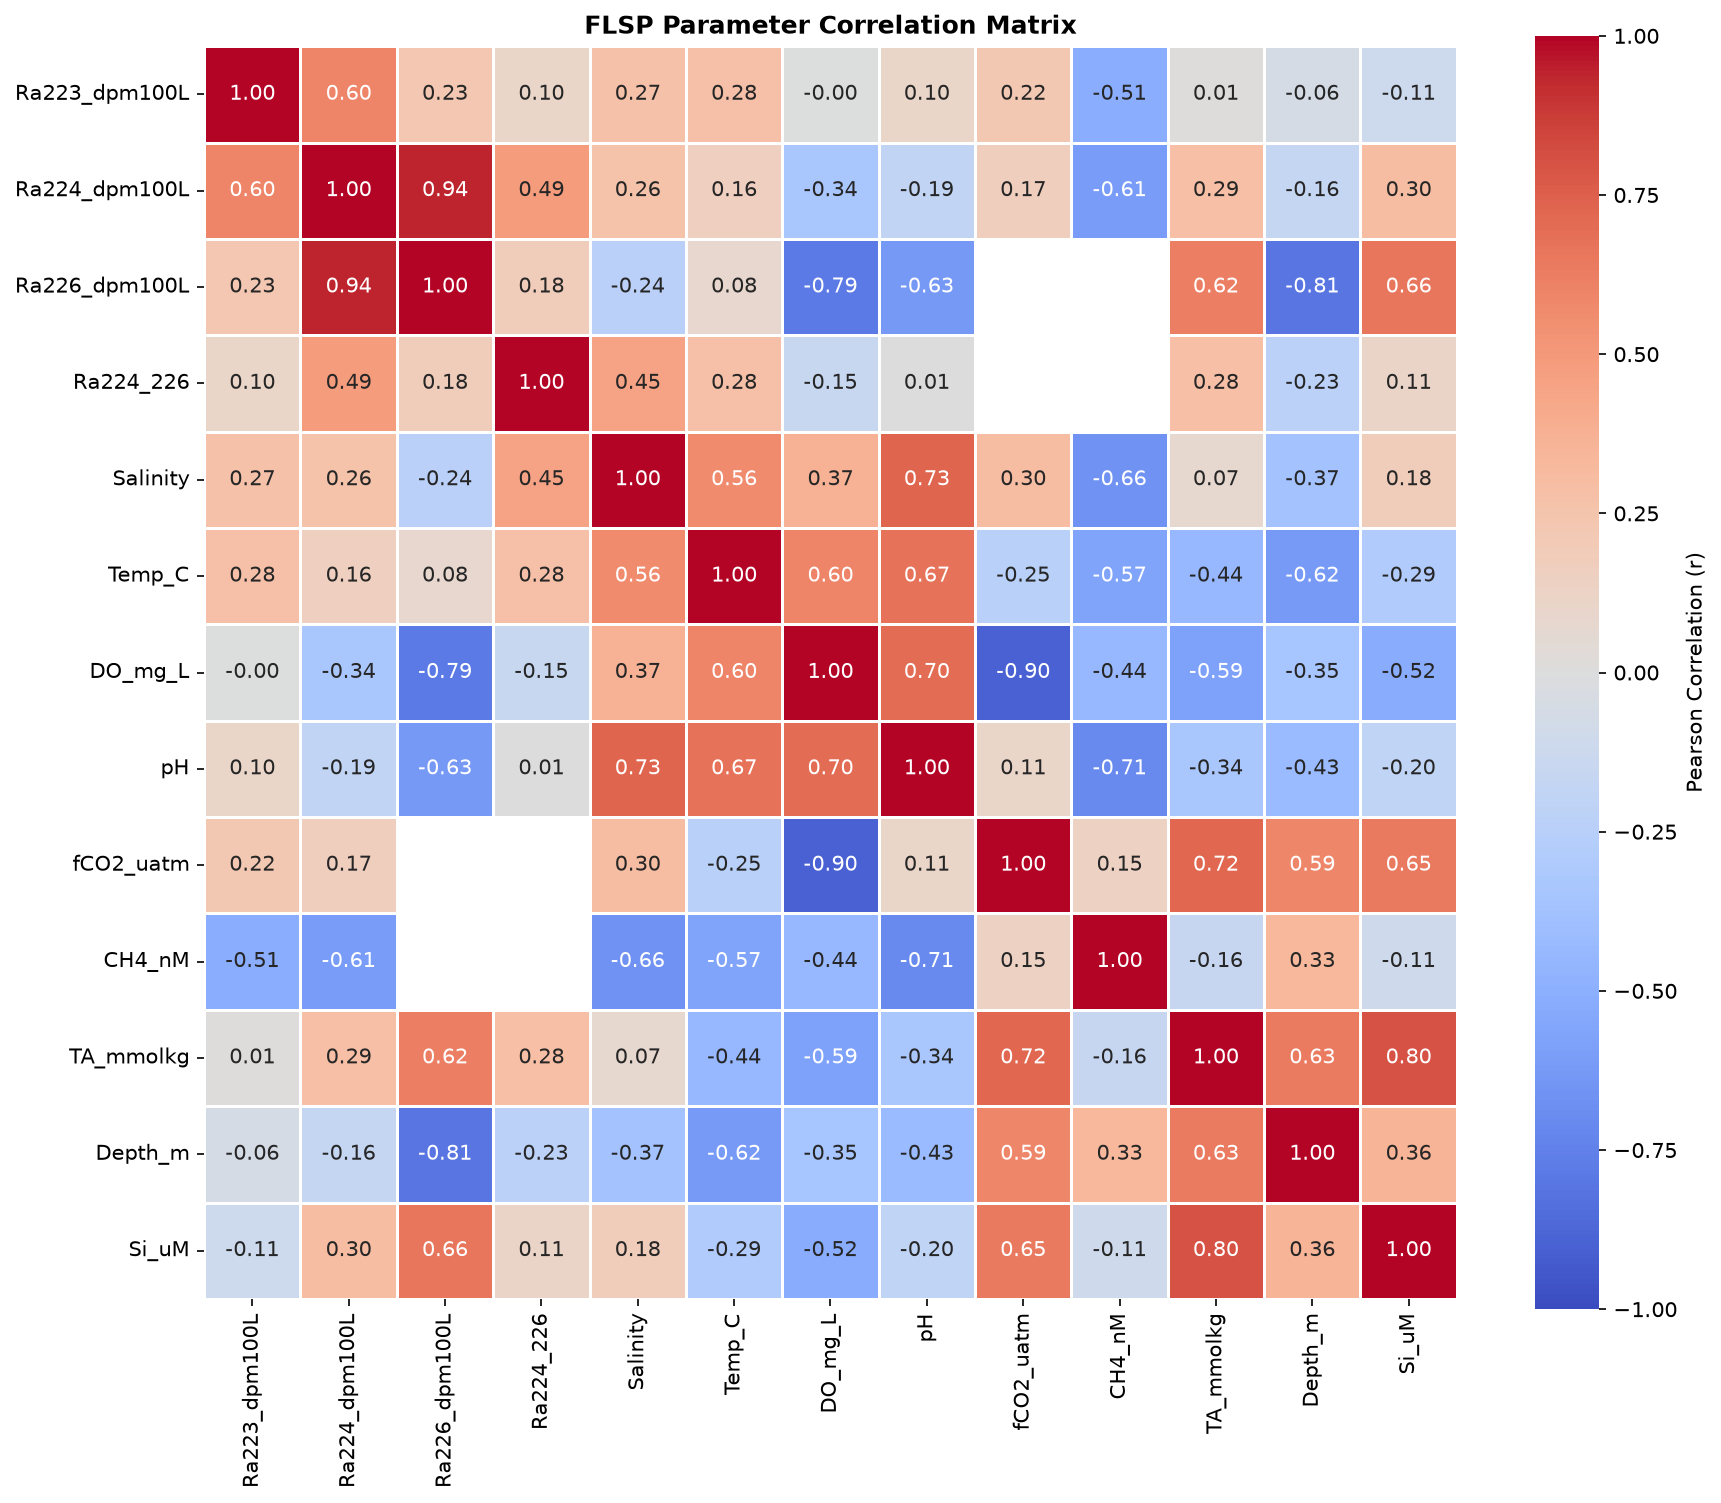

In [81]:
# calculate correlation matrix for key variables at FLSP
flsp_corr = data_flsp[flsp_vars].corr(numeric_only=True) # compute linear correlation coefficients

# plot visual correlation matrix heatmap
plt.figure(figsize=(12, 10), dpi=150) 

# draw heatmap with colorbar and values formatted to 2 decimal places
sns.heatmap(flsp_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson Correlation (r)'}) 

plt.title('FLSP Parameter Correlation Matrix', fontsize=12, fontweight='bold') 
plt.tight_layout() 
plt.show() 

Ra224 and 226 correlate highly with each other, which may make this justification in picking these isotopes for my endmember mixing model (keeping in mind we still need PW and GW 226). Si and Ra226 moderatly correlate with each other and TA and Si highly correlate with each other, which is all good since they're derived from the same source. 

In [83]:
# group by Sample_Type and Tidal_Cycle for SW only 
sw_data = data_flsp[data_flsp['Sample_Type'] == 'SW']
flsp_breakdown = sw_data.groupby(['Sample_Type','Tidal_Cycle'])[flsp_vars].agg(['mean', 'std'])

# transpose so parameters are stacked vertically for clean reading
display(flsp_breakdown.T)

Sample_Type                 SW            
Tidal_Cycle               neap      spring
Ra223_dpm100L mean    7.167242    7.346375
              std     1.913120    1.636492
Ra224_dpm100L mean  144.733201  118.186167
              std    61.887584   42.610056
Ra226_dpm100L mean   43.784088   33.276051
              std    13.699912   11.741977
Ra224_226     mean    3.197984    3.544384
              std     0.428219    0.365854
Salinity      mean   26.680000   27.285000
              std     0.738529    0.647365
Temp_C        mean   33.047778   34.260833
              std     2.514785    2.351036
DO_mg_L       mean    3.980222    5.448167
              std     1.561480    0.776294
pH            mean    7.307556    7.547500
              std     0.398389    0.347217
fCO2_uatm     mean         NaN         NaN
              std          NaN         NaN
CH4_nM        mean         NaN         NaN
              std          NaN         NaN
TA_mmolkg     mean    2.336500    1.944729
              std     0.367727    0.101355
Depth_m       mean    0.352722    0.547292
              std     0.128288    0.203595
Si_uM         mean   64.406667   52.462222
              std    13.140945   14.427074

Ra224 and 226 were highest in the channel during the neap tide, along with TA and Si. All water quality parameters were higher during spring tide. Water depth was on average higher during spring tide. 

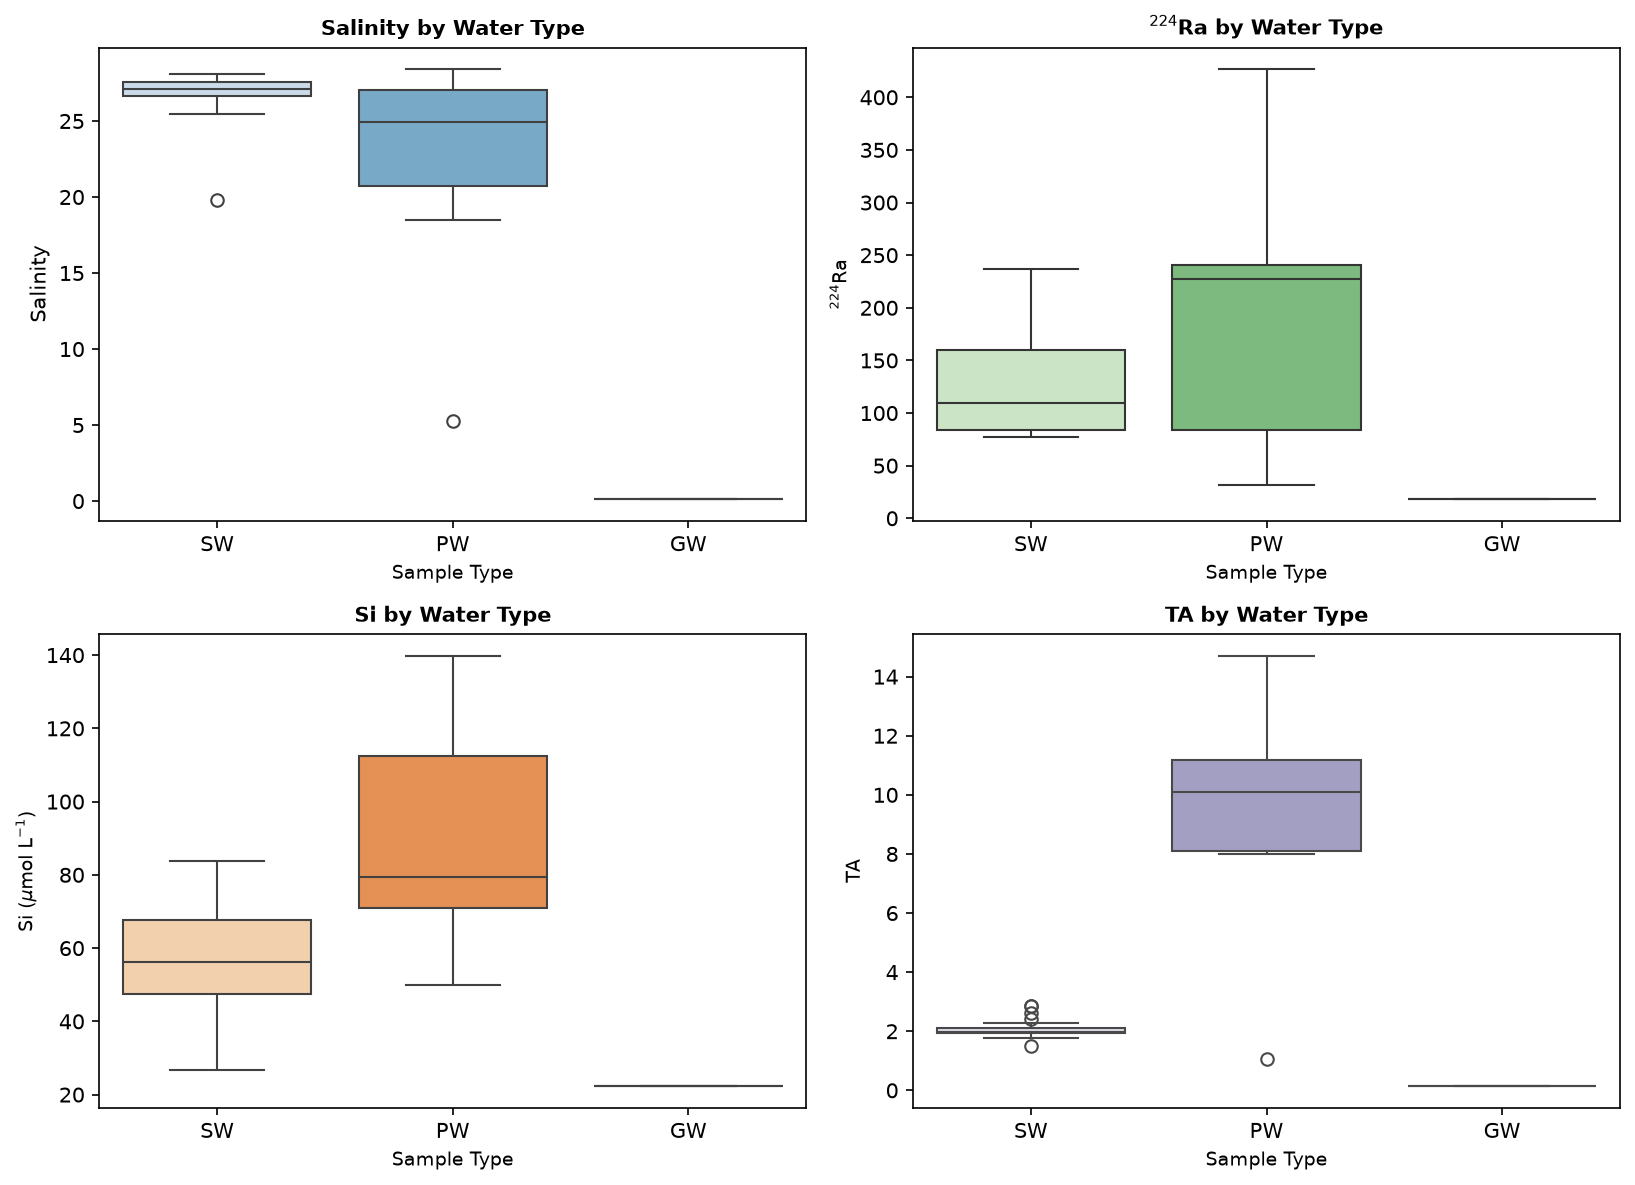

In [86]:
# create 2x2 grid of boxplots comparing parameters across Sample_Type (overall baseline)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), dpi=150)

# plot 1: Salinity across water types
sns.boxplot(data=data_flsp, x='Sample_Type', y='Salinity', hue='Sample_Type', legend=False, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Salinity by Water Type', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Sample Type', fontsize=9)

# plot 2: Ra-224 across water types
sns.boxplot(data=data_flsp, x='Sample_Type', y='Ra224_dpm100L', hue='Sample_Type', legend=False, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('$^{224}$Ra by Water Type', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Sample Type', fontsize=9)
axes[0, 1].set_ylabel('$^{224}$Ra', fontsize=9)

# plot 3: Si across water types
sns.boxplot(data=data_flsp, x='Sample_Type', y='Si_uM', hue='Sample_Type', legend=False, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('Si by Water Type', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sample Type', fontsize=9)
axes[1, 0].set_ylabel(r'Si ($\mu$mol L$^{-1}$)', fontsize=9) # added raw string r'...' to fix \mu warning

# plot 4: TA across water types
sns.boxplot(data=data_flsp, x='Sample_Type', y=ta_col, hue='Sample_Type', legend=False, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('TA by Water Type', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Sample Type', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

Ra224 activity, salinity, Si, and TA all seem to be statistically different in GW vs SW and PW, which gives me clarity I captured my groundwater endmember. 

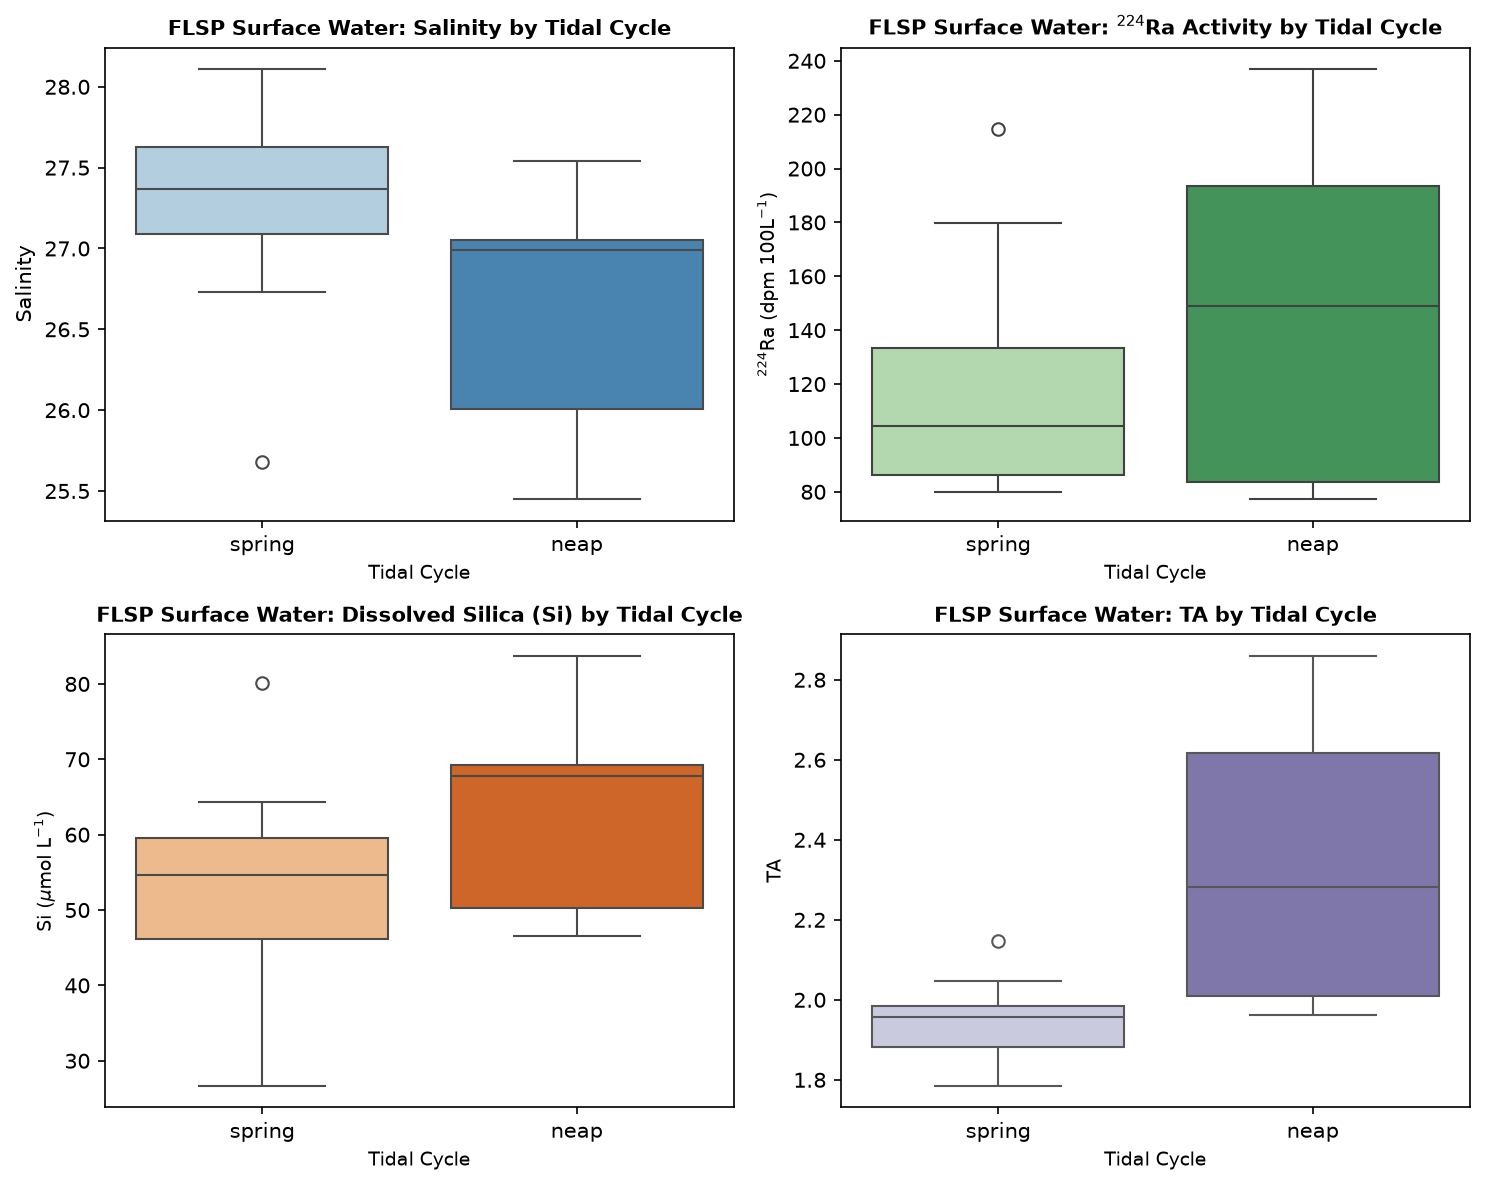

In [90]:
# filter for Surface Water only
flsp_sw = data_flsp[data_flsp['Sample_Type'] == 'SW'].copy()

# create 2x2 grid of boxplots for SW across Tidal_Cycle
fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=150)

# plot 1: Salinity
sns.boxplot(data=flsp_sw, x='Tidal_Cycle', y='Salinity', hue='Tidal_Cycle', legend=False, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('FLSP Surface Water: Salinity by Tidal Cycle', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Tidal Cycle', fontsize=9)

# plot 2: Ra-224
sns.boxplot(data=flsp_sw, x='Tidal_Cycle', y='Ra224_dpm100L', hue='Tidal_Cycle', legend=False, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title(r'FLSP Surface Water: $^{224}$Ra Activity by Tidal Cycle', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('Tidal Cycle', fontsize=9)
axes[0, 1].set_ylabel(r'$^{224}$Ra (dpm 100L$^{-1}$)', fontsize=9)

# plot 3: Dissolved Silica (Si)
sns.boxplot(data=flsp_sw, x='Tidal_Cycle', y='Si_uM', hue='Tidal_Cycle', legend=False, ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('FLSP Surface Water: Dissolved Silica (Si) by Tidal Cycle', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Tidal Cycle', fontsize=9)
axes[1, 0].set_ylabel(r'Si ($\mu$mol L$^{-1}$)', fontsize=9)

# plot 4: Total Alkalinity (TA)
sns.boxplot(data=flsp_sw, x='Tidal_Cycle', y=ta_col, hue='Tidal_Cycle', legend=False, ax=axes[1, 1], palette='Purples')
axes[1, 1].set_title('FLSP Surface Water: TA by Tidal Cycle', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Tidal Cycle', fontsize=9)
axes[1, 1].set_ylabel('TA', fontsize=9)

plt.tight_layout()
plt.show()

There doesn't seem to be any significant differences between spring and neap tides. There is one outlier in all plots for the spring tide, and I'm curious if it's the same data point.

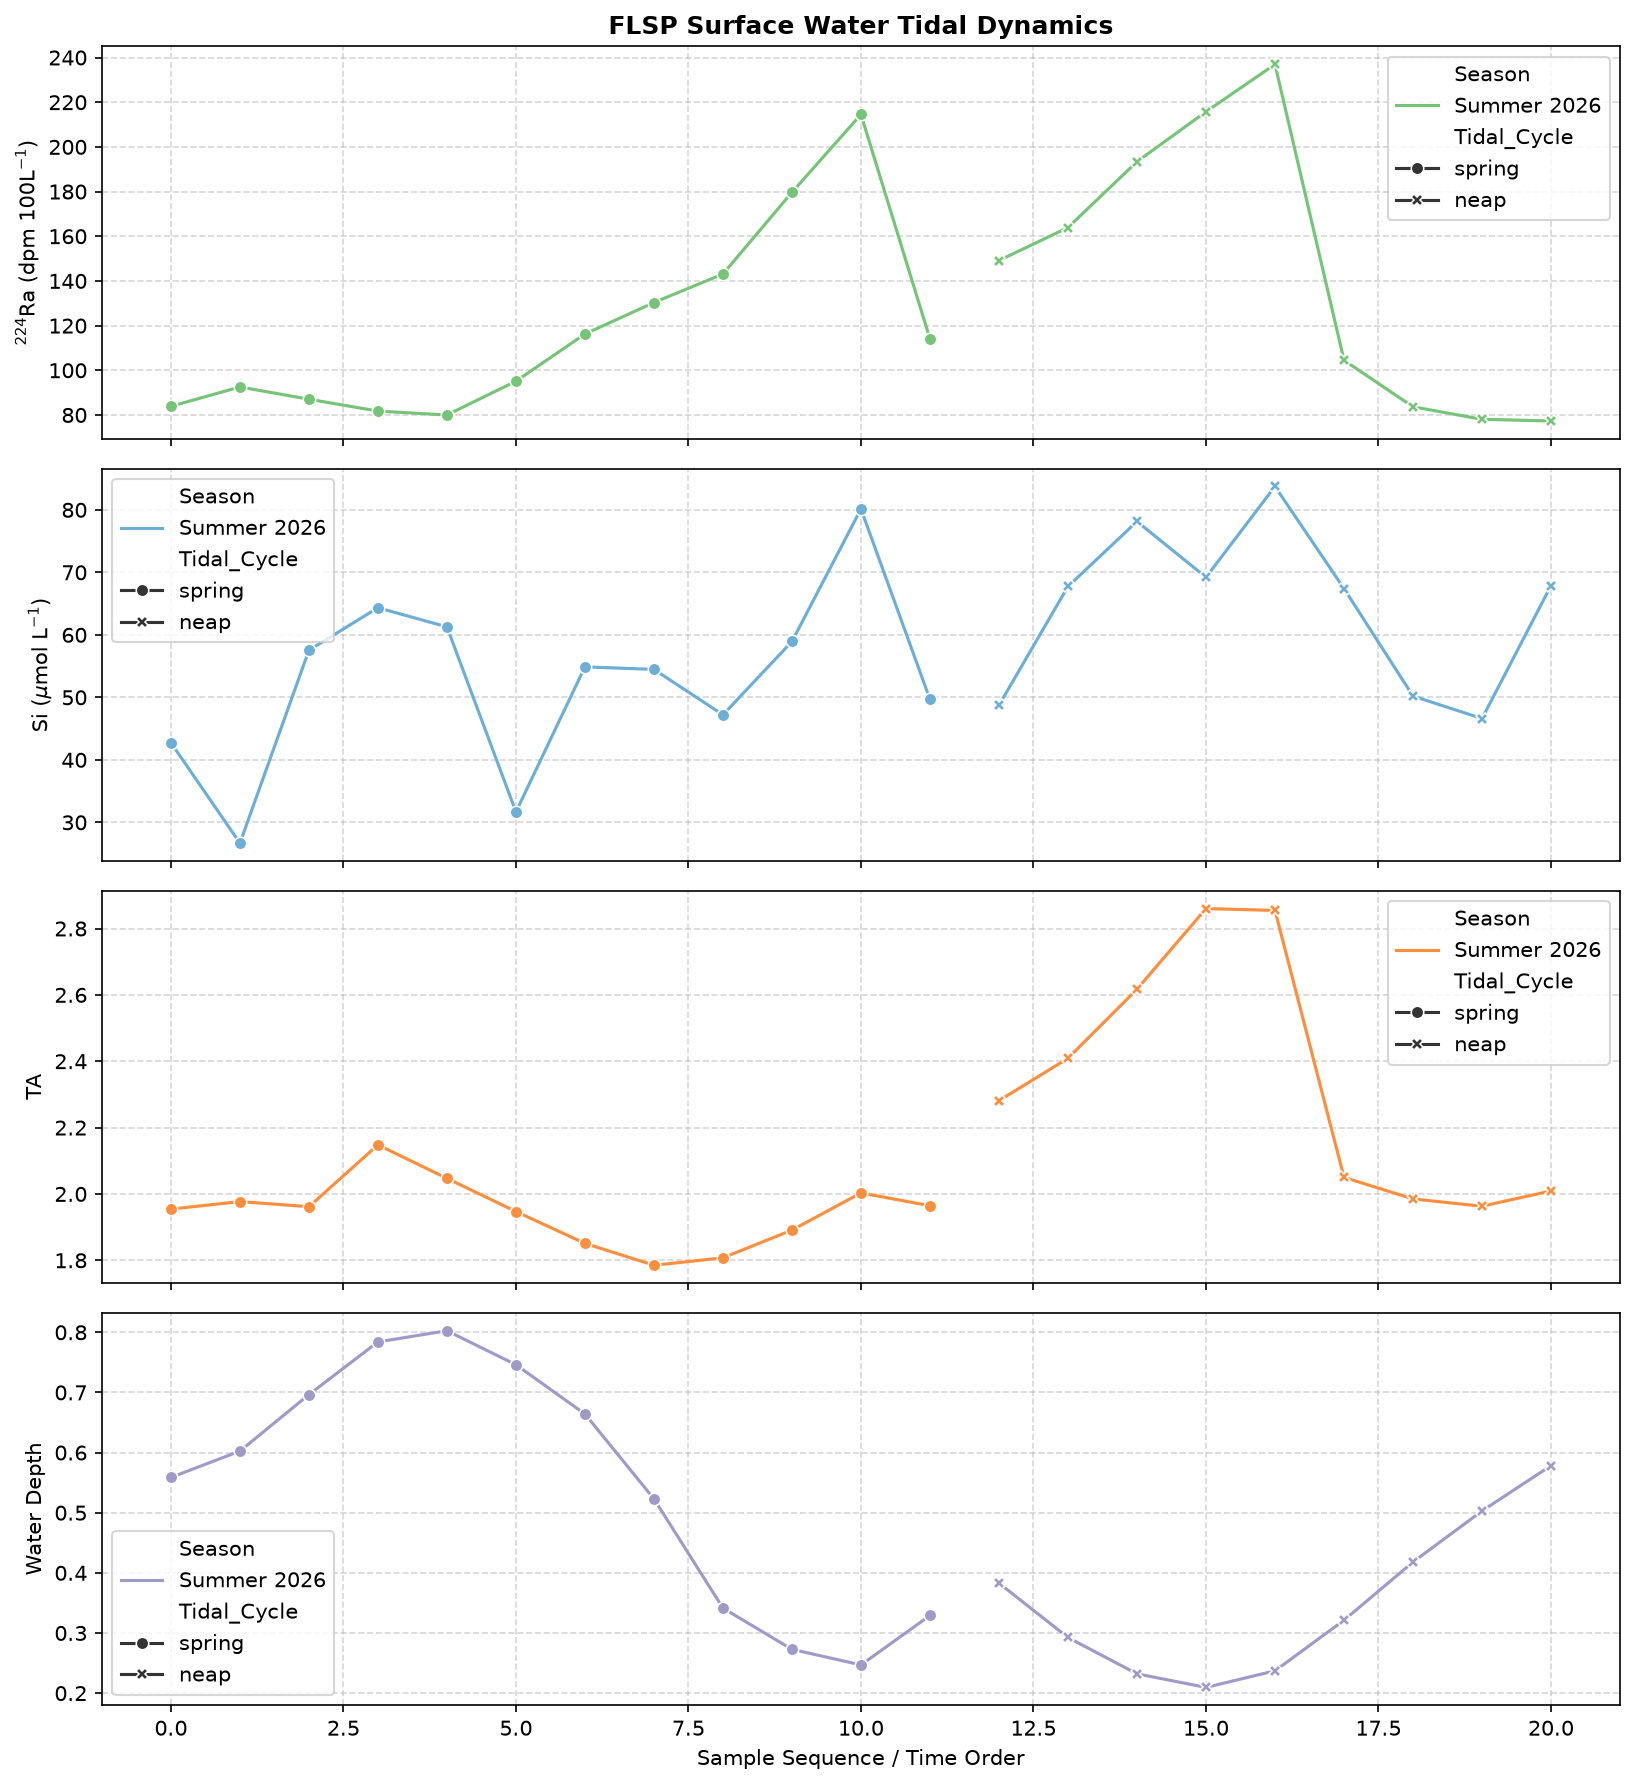

In [91]:
# filter for Surface Water only
sw_only = data_flsp[data_flsp['Sample_Type'] == 'SW'].copy()

# create 4-panel stacked time-series plot
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True, dpi=150)

# plot 1: Ra-224 over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='Ra224_dpm100L', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[0], palette='Greens_r')
axes[0].set_title('FLSP Surface Water Tidal Dynamics', fontsize=12, fontweight='bold')
axes[0].set_ylabel(r'$^{224}$Ra (dpm 100L$^{-1}$)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# plot 2: Si over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='Si_uM', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[1], palette='Blues_r')
axes[1].set_ylabel(r'Si ($\mu$mol L$^{-1}$)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

# plot 3: TA over Tidal Cycle
sns.lineplot(data=sw_only, x=sw_only.index, y='TA_mmolkg', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[2], palette='Oranges_r')
axes[2].set_ylabel('TA', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.5)

# plot 4: Water Depth over Tidal Cycle (Tidal Stage Indicator)
sns.lineplot(data=sw_only, x=sw_only.index, y='Depth_m', hue='Season', style='Tidal_Cycle', 
             markers=True, dashes=False, ax=axes[3], palette='Purples_r')
axes[3].set_ylabel('Water Depth', fontsize=10)
axes[3].set_xlabel('Sample Sequence / Time Order', fontsize=10)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The Ra224 and TA plots are inverses of the water depth plot, which is what we expect if there is SGD and PEX influence due to the hydraulic gradient. Si generally follows this pattern for the neap tide, but not so much the spring.

This will end my EDA for now. There's so much data and a lot to analyze holy cows. I'm pretty stoked to see how these variables will compare spatially across sites. Stay tuned. 